# TCP Propensity Model

**Objective:** Predict likelihood of companies joining TCP (Joined_tcp) using company emissions, targets, and disclosure features.


**Notebook overview**  
1. **Load data** -> Read company data from CSV.  
2. **Explore features** -> Look at structural, commitment , disclouser, filmographic features.  
3. **Engineer features** -> Clean and transform columns for modeling.  
4. **PCA visualization** -> Plot companies in 2D to see if joiners vs non-joiners look different.  
5. **Modeling 1 (Standard)** -> Train XGBoost assuming all labels are correct; get join probabilities.  
6. **Modeling 2 (PU Bagging)** -> Train with Positive-Unlabeled logic; compare which approach ranks companies better for TCP outreach.
7. **Fine Tuning PU Bagging** -> Used CV Grid search for hyperparameters to fine tune the model.
8. **Propensity Score** -> Create csv containg propensity score generated by fine tuned model and ranking based on propensity score.

## 1. Imports & Setup


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from pathlib import Path

import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
)

TARGET_COL = 'Joined_tcp'

## 2. Data Loading


In [3]:

df = pd.read_csv(r'C:\Users\Nidhi\Downloads\Capstone_companies_data.csv', encoding='latin1')
# Coerce numeric columns: CSV may load emissions/revenue as strings (e.g. scientific notation).
numeric_cols = [
    'scope1', 'scope2_location', 'scope2_market', 'scope3', 'revenue', 'employees',
    'baseline_scope1', 'baseline_scope2',
    'y1_scope1', 'y1_scope2_location', 'y1_scope2_market', 'y1_scope3',
    'y2_scope1', 'y2_scope2_location', 'y2_scope2_market', 'y2_scope3',
    'y3_scope1', 'y3_scope2_location', 'y3_scope2_market', 'y3_scope3',
    'y4_scope1', 'y4_scope2_location', 'y4_scope2_market', 'y4_scope3',
    'change_pct_s1s2',
    'missing_s1s2_near_abs_pct', 'missing_s3_near_abs_pct', 'scope3_category_count_near',
    'has_near_term_target', 'ambition_level_nearterm', 'ambition_level_longterm',
]
for c in numeric_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')
print(f"Shape: {df.shape}")
print(f"Columns: {len(df.columns)}")
df.head()

Shape: (5020, 60)
Columns: 60


,company_name_sbti,sbti_id,company_name_clean,isin,lei,organization_type,location,region,sector,has_near_term_target,...,y4_scope2_location,y4_scope2_market,y4_scope3,revenue,employees,Joined_tcp,race_to_zero,RE100,EV100,in_cdp
0,AcBel Polytech Inc.,40009754.0,ACBEL POLYTECH,TW0006282007,254900BQVM5V0IY7RQ62,Corporate,"Taiwan, Province of China",Asia,Technology Hardware and Equipment,1.0,...,34950.85,NaN,NaN,8.318650e+08,983.0,0,0,0,0,1
1,Chalhoub Group,40008140.0,CHALHOUB GROUP,NaN,NaN,Corporate,United Arab Emirates,MENA,Retailing,1.0,...,NaN,NaN,NaN,1.280000e+10,16000.0,0,1,0,0,0
2,Cloudfm Group Limited,40006454.0,CLOUDFM GROUP,NaN,NaN,SME,United Kingdom,Europe,Real Estate,1.0,...,NaN,NaN,NaN,6.245059e+07,212.0,0,1,0,0,0
3,Drax Group plc,40012691.0,DRAX GROUP,GB00B1VNSX38,549300YPSNTXR4ZHSR98,Corporate,United Kingdom,Europe,Electric Utilities and Independent Power Produ...,1.0,...,251889.00,251162.0,2249201.0,9.400000e+09,3250.0,0,1,0,0,1
4,Fater S.p.A.,40006049.0,FATER,NaN,8156001747635D7D4A58,Corporate,Italy,Europe,"Consumer Durables, Household and Personal Prod...",1.0,...,NaN,NaN,NaN,1.070346e+09,1768.0,0,1,0,0,0


In [4]:
print(f"Target {TARGET_COL} distribution:")
print(df[TARGET_COL].value_counts())
print(f"\nProportions:")
print(df[TARGET_COL].value_counts(normalize=True))

Target Joined_tcp distribution:
Joined_tcp
0    4724
1     296
Name: count, dtype: int64

Proportions:
Joined_tcp
0    0.941036
1    0.058964
Name: proportion, dtype: float64



- **Target distribution:** About 94% did not join TCP (0) and ~6% joined (1). This is *class imbalance* joiners are rare.  


## 3. Data Cleaning

#### 3.1 Removing Duplicate Rows

In [5]:
# Find rows with same sbti_id (duplicate companies) - exclude NaN sbti_id
# Removing duplicate rows

if 'sbti_id' in df.columns:
    valid = df['sbti_id'].notna()
    dup_mask = valid & df.duplicated(subset=['sbti_id'], keep=False)
    dup_sbti = df.loc[dup_mask].groupby('sbti_id').apply(lambda g: g.index.tolist()).to_dict()
    print(f"sbti_ids with duplicates: {len(dup_sbti)}")
    print("Row indexes by sbti_id:")
    for sid, idx_list in list(dup_sbti.items())[:15]:
        print(f"  sbti_id={sid}: {idx_list}")
    
    # All duplicate row indexes (flat list)
    dup_indexes = [i for idx_list in dup_sbti.values() for i in idx_list]
    print(f"\nAll duplicate row indexes ({len(dup_indexes)} total): {dup_indexes[:30]}..." if len(dup_indexes)>30 else f"\nAll duplicate row indexes: {dup_indexes}")
else:
    print("sbti_id column not found.")

sbti_ids with duplicates: 126
Row indexes by sbti_id:
  sbti_id=40000141.0: [298, 1532]
  sbti_id=40000224.0: [2047, 4991]
  sbti_id=40000259.0: [948, 4832]
  sbti_id=40000418.0: [4720, 4755]
  sbti_id=40000508.0: [752, 4810]
  sbti_id=40000692.0: [815, 816]
  sbti_id=40000722.0: [994, 4840]
  sbti_id=40000858.0: [553, 4788]
  sbti_id=40001009.0: [1525, 4911]
  sbti_id=40001041.0: [1331, 3783]
  sbti_id=40001092.0: [206, 207]
  sbti_id=40001313.0: [921, 4433]
  sbti_id=40001556.0: [3258, 4830]
  sbti_id=40001698.0: [70, 4725]
  sbti_id=40001893.0: [4817, 4818]

All duplicate row indexes (268 total): [298, 1532, 2047, 4991, 948, 4832, 4720, 4755, 752, 4810, 815, 816, 994, 4840, 553, 4788, 1525, 4911, 1331, 3783, 206, 207, 921, 4433, 3258, 4830, 70, 4725, 4817, 4818]...


In [6]:
# Drop duplicates by sbti_id (keep higher-index row). Exclude NaN sbti_id.

if 'sbti_id' in df.columns:
    valid = df['sbti_id'].notna()
    to_drop = valid & df.duplicated(subset=['sbti_id'], keep='last')
    dropped_df = df[to_drop].copy()
    n_dropped = len(dropped_df)
    print(f"Rows that will be dropped: {n_dropped}")
    if n_dropped > 0:
        cols = [c for c in ['sbti_id', 'company_name_sbti'] if c in df.columns]
        display(dropped_df[cols])
    n_before = len(df)
    df_valid = df[valid].drop_duplicates(subset=['sbti_id'], keep='last')
    df_nan = df[~valid]
    df = pd.concat([df_valid, df_nan], ignore_index=True)
    n_dropped = n_before - len(df)
    print(f"\nDropped {n_dropped} duplicate rows (by sbti_id). Kept higher-index row per company.")
    print(f"Shape: {df.shape[0]} rows (was {n_before})")
else:
    to_drop = df.duplicated(keep='last')
    dropped_df = df[to_drop]
    print(f"Rows that will be dropped: {len(dropped_df)}")
    display(dropped_df)  # or print(dropped_df)
    df = df.drop_duplicates(keep='last').reset_index(drop=True)
    print("Dropped full row duplicates (no sbti_id column). Kept higher-index row.")

Rows that will be dropped: 142


,sbti_id,company_name_sbti
16,40005499.0,Vattenfall AB
41,40005696.0,ReNew Energy Global PLC
45,40014667.0,Virgin Media O2
52,40022320.0,industria co.ltd
70,40001698.0,Accenture
...,...,...
4838,40004394.0,henkel
4885,40014039.0,Maersk
4904,40002195.0,MUNDYS
4917,40013886.0,Paack Logistics



Dropped 142 duplicate rows (by sbti_id). Kept higher-index row per company.
Shape: 4878 rows (was 5020)


###@ 3.2 Domain Validation Check

This step checks for values that do not make sense based on expected data rules. Percent columns should stay between -100 and 100, revenue and emissions columns should not be negative, and employee counts should be greater than zero.


In [7]:
# Domain validation: summarize issues and drop bad rows from df

pct_cols = ["missing_s1s2_near_abs_pct", "missing_s3_near_abs_pct", "change_pct_s1s2"]
pct_cols = [c for c in pct_cols if c in df.columns]

pos_cols = ["revenue", "scope1", "scope2_location", "scope2_market", "scope3"]
pos_cols = [c for c in pos_cols if c in df.columns]

drop_mask = pd.Series(False, index=df.index)

print("Domain validation summary:")

# Check percent columns should be between -100 and 100
for col in pct_cols:
    s = pd.to_numeric(df[col], errors="coerce")
    mask = (s < -100) | (s > 100)

    print(f"{col} outside [-100, 100]: {int(mask.sum())} rows")
    drop_mask |= mask

# Check revenue and emissions should not be negative
for col in pos_cols:
    s = pd.to_numeric(df[col], errors="coerce")
    mask = s < 0

    print(f"{col} negative: {int(mask.sum())} rows")
    drop_mask |= mask

# Check employees should be greater than 0
if "employees" in df.columns:
    s = pd.to_numeric(df["employees"], errors="coerce")
    mask = s <= 0

    print(f"employees <= 0: {int(mask.sum())} rows")
    drop_mask |= mask

# Drop rows that failed any rule
n_before = len(df)
n_drop = int(drop_mask.sum())

print(f"\nTotal unique rows to drop: {n_drop}")

df = df.loc[~drop_mask].reset_index(drop=True)

print(f"Rows before: {n_before}")
print(f"Rows after: {len(df)}")
print(f"New shape: {df.shape}")

Domain validation summary:
missing_s1s2_near_abs_pct outside [-100, 100]: 0 rows
missing_s3_near_abs_pct outside [-100, 100]: 0 rows
change_pct_s1s2 outside [-100, 100]: 3 rows
revenue negative: 1 rows
scope1 negative: 0 rows
scope2_location negative: 0 rows
scope2_market negative: 0 rows
scope3 negative: 0 rows
employees <= 0: 0 rows

Total unique rows to drop: 4
Rows before: 4878
Rows after: 4874
New shape: (4874, 60)


In [8]:
#  Drop rows that failed domain validation 

n_before = len(df)
n_drop = int(drop_mask.sum())

print(f"Rows to drop: {n_drop}")

# Drop rows and reset index
df = df.loc[~drop_mask].reset_index(drop=True)

print(f"Rows before: {n_before}")
print(f"Rows after: {len(df)}")
print(f"New shape: {df.shape}")

Rows to drop: 4
Rows before: 4874
Rows after: 4870
New shape: (4870, 60)


In [9]:
# Descriptive statistics after cleaning
# This helps check spread and possible remaining outliers

check_cols = [
    "revenue",
    "scope1",
    "scope2_location",
    "scope2_market",
    "scope3",
    "employees"
]

# Keep only columns that exist in df
check_cols = [c for c in check_cols if c in df.columns]

print("Descriptive Statistics After Cleaning")
print("=" * 70)

summary = df[check_cols].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
).T

# Add extra useful columns
summary["range"] = summary["max"] - summary["min"]
summary["iqr"] = summary["75%"] - summary["25%"]
summary["median"] = df[check_cols].median()

display(summary[["count", "min", "25%", "50%", "75%", "95%", "99%", "max", "iqr", "median"]])


Descriptive Statistics After Cleaning


,count,min,25%,50%,75%,95%,99%,max,iqr,median
revenue,4799.0,0.0000,2.000000e+08,1.500000e+09,8.252674e+09,5.123570e+10,5.941200e+11,7.530000e+12,8.052674e+09,1.500000e+09
scope1,4650.0,0.0004,6.292500e+02,5.920060e+03,8.626725e+04,9.030000e+06,1.013799e+10,7.010000e+12,8.563800e+04,5.920060e+03
scope2_location,4345.0,0.0002,9.290000e+02,1.232930e+04,1.491060e+05,9.670000e+06,1.413884e+10,6.730000e+12,1.481770e+05,1.232930e+04
scope2_market,2553.0,0.0100,1.707000e+03,1.517900e+04,1.558200e+05,6.610000e+06,8.077280e+08,3.160000e+11,1.541130e+05,1.517900e+04
scope3,4135.0,0.0057,9.145535e+03,2.091634e+05,2.651372e+06,6.365700e+08,5.540967e+10,2.290000e+13,2.642226e+06,2.091634e+05
employees,4424.0,5.0000,3.860000e+02,3.035500e+03,1.500000e+04,1.030000e+05,3.395400e+05,4.000000e+06,1.461400e+04,3.035500e+03


In [10]:
# Domain cleaning: remove unrealistic values

drop_mask = pd.Series(False, index=df.index)

# Revenue (remove > 1 trillion)
if "revenue" in df.columns:
    mask = df["revenue"] > 1e12
    print(f"revenue > 1T: {mask.sum()}")
    drop_mask |= mask

# Scope1
if "scope1" in df.columns:
    mask = df["scope1"] > 1e10
    print(f"scope1 too large: {mask.sum()}")
    drop_mask |= mask

# Scope2 location
if "scope2_location" in df.columns:
    mask = df["scope2_location"] > 1e10
    print(f"scope2_location too large: {mask.sum()}")
    drop_mask |= mask

# Scope2 market
if "scope2_market" in df.columns:
    mask = df["scope2_market"] > 1e10
    print(f"scope2_market too large: {mask.sum()}")
    drop_mask |= mask

# Scope3
if "scope3" in df.columns:
    mask = df["scope3"] > 1e11
    print(f"scope3 too large: {mask.sum()}")
    drop_mask |= mask

# Employees
if "employees" in df.columns:
    mask = (df["employees"] <= 0) | (df["employees"] > 1e6)
    print(f"employees invalid: {mask.sum()}")
    drop_mask |= mask

# Drop rows
n_before = len(df)
n_drop = drop_mask.sum()

print(f"\nTotal rows to drop: {n_drop}")


revenue > 1T: 30
scope1 too large: 47
scope2_location too large: 48
scope2_market too large: 15
scope3 too large: 33
employees invalid: 6

Total rows to drop: 99


In [11]:
df = df.loc[~drop_mask].reset_index(drop=True)

print(f"Rows before: {n_before}")
print(f"Rows after: {len(df)}")
print(f"New shape: {df.shape}")

Rows before: 4870
Rows after: 4771
New shape: (4771, 60)




#### 3.3 Modified Z-Score Outlier Detection for Non-TCP Rows

* This step detects outliers using only the non-TCP companies where `Joined_tcp == 0`. TCP joiners are not included in the outlier detection process and are not removed.

* Because revenue and emissions data are highly skewed, each column is first transformed using `log1p()`. Then, the modified z-score is calculated using the median and MAD instead of the mean and standard deviation.

* A non-TCP row is flagged as an outlier if:

\[
Modified\ Z > 3.5
\]

* This method is more robust because the median is less affected by very large companies. The cell reports the number of outliers for each column and shows the top 5 largest flagged values. It only stores the flagged row indexes in `outlier_rows`; it does not drop rows yet. The selected columns are not replaced with z-scores. The z-scores are only used temporarily for outlier screening.


In [12]:
# Modified z-score outlier detection using only non-TCP rows
# TCP joiners are not used or removed in this step

check_cols = ["revenue", "scope1", "scope2_location", "scope2_market", "scope3"]
check_cols = [c for c in check_cols if c in df.columns]

MOD_Z_THRESH = 3.5

non_tcp_mask = df[TARGET_COL].eq(0)

outlier_rows = []

print("Modified Z-Score Outlier Detection: Non-TCP Rows Only")
print("=" * 65)

for col in check_cols:
    # Use only positive, non-missing values from non-TCP rows
    values = pd.to_numeric(df.loc[non_tcp_mask, col], errors="coerce")
    values = values[values.notna() & (values > 0)]

    # Log transform to reduce skew
    log_values = np.log1p(values)

    # Median and MAD
    median = np.median(log_values)
    mad = np.median(np.abs(log_values - median))

    # Avoid division by zero
    if mad == 0 or np.isnan(mad):
        mad = 1e-9

    # Calculate modified z-score
    modified_z = 0.6745 * np.abs(log_values - median) / mad

    # Flag outliers
    mask = modified_z > MOD_Z_THRESH
    outliers = values[mask]

    print(f"\n{col}: {len(outliers)} non-TCP outliers")
    print(f"Median log value: {median:.4f}")
    print(f"MAD: {mad:.4f}")

    # Show top 5 largest outliers
    if len(outliers) > 0:
        print("Top 5 largest values:")

        for idx, val in outliers.sort_values(ascending=False).head(5).items():
            if "company_name_clean" in df.columns:
                company = df.loc[idx, "company_name_clean"]
                print(f"  {company}: {val:,.0f}")
            else:
                print(f"  Row {idx}: {val:,.0f}")

        outlier_rows.extend(outliers.index.tolist())

# Keep only unique row indexes
outlier_rows = sorted(set(outlier_rows))

print("\nSummary")
print("-" * 30)
print(f"Total unique non-TCP rows flagged: {len(outlier_rows)}")
print(f"TCP joiners flagged/removed: 0")

Modified Z-Score Outlier Detection: Non-TCP Rows Only

revenue: 1 non-TCP outliers
Median log value: 21.1152
MAD: 1.7395
Top 5 largest values:
  BEIJING XINGLINTIAN TRANSLATION CENTER: 140,252

scope1: 7 non-TCP outliers
Median log value: 8.5674
MAD: 2.4347
Top 5 largest values:
  SOCAPS: 4,676,000,000
  GREENWASTE: 3,336,000,000
  HERO GROUP: 2,940,250,000
  IQHQ: 2,722,000,000
  NORDOX AS: 2,555,000,000

scope2_location: 3 non-TCP outliers
Median log value: 9.3699
MAD: 2.4742
Top 5 largest values:
  VIRGIN MEDIA IRELAND: 7,513,000,000
  ARTEREX: 7,088,000,000
  NEWAGE INDUSTRIES: 5,578,000,000

scope2_market: 4 non-TCP outliers
Median log value: 9.5366
MAD: 2.2824
Top 5 largest values:
  ACUMATICA: 5,946,000,000
  IQHQ: 3,818,000,000
  GREENWASTE: 3,566,000,000
  ADAPTIVE BIOTECHNOLOGIES: 2,208,570,000

scope3: 0 non-TCP outliers
Median log value: 12.2162
MAD: 2.7502

Summary
------------------------------
Total unique non-TCP rows flagged: 12
TCP joiners flagged/removed: 0


* Large standard deviations across emissions and revenue suggest high variability in the data, so it is important to isolate extreme outlier

In [13]:
# Drop the flagged non-TCP modified z-score outliers

n_before = len(df)
n_drop = len(outlier_rows)

print(f"Rows to drop: {n_drop}")

df = df.drop(index=outlier_rows).reset_index(drop=True)

print(f"Rows before: {n_before}")
print(f"Rows dropped: {n_drop}")
print(f"Rows after: {len(df)}")
print(f"New shape: {df.shape}")

# Check class counts after dropping
print(df[TARGET_COL].value_counts())

Rows to drop: 12
Rows before: 4771
Rows dropped: 12
Rows after: 4759
New shape: (4759, 60)
Joined_tcp
0    4479
1     280
Name: count, dtype: int64


In [14]:
# Check summary statistics after removing non-TCP outliers

check_cols = ["revenue", "scope1", "scope2_location", "scope2_market", "scope3"]
check_cols = [c for c in check_cols if c in df.columns]

non_tcp = df[TARGET_COL].eq(0)

non_tcp_summary = df.loc[non_tcp, check_cols].agg(
    ["count", "min", "max", "mean", "std", "median"]
).T

display(non_tcp_summary)

,count,min,max,mean,std,median
revenue,4409.0,0.0000,9.960000e+11,1.328419e+10,5.765392e+10,1.481000e+09
scope1,4296.0,0.0004,1.593000e+09,3.747653e+06,5.080573e+07,5.147000e+03
scope2_location,4005.0,0.0002,3.199000e+09,4.675503e+06,8.124719e+07,1.154100e+04
scope2_market,2392.0,0.0200,1.112035e+09,2.511237e+06,3.954001e+07,1.380150e+04
scope3,3815.0,0.0057,3.587300e+10,8.938236e+07,1.215990e+09,2.011480e+05


In [15]:
print(f"Target {TARGET_COL} distribution:")
print(df[TARGET_COL].value_counts())
print(f"\nProportions:")
print(df[TARGET_COL].value_counts(normalize=True))

Target Joined_tcp distribution:
Joined_tcp
0    4479
1     280
Name: count, dtype: int64

Proportions:
Joined_tcp
0    0.941164
1    0.058836
Name: proportion, dtype: float64


## 4. Feature Exploration - Raw Data

**What we are going to do:**  
We explore the raw columns in our dataset. We group them into: (1) structural features (emissions, revenue, employees), (2) commitment features (targets, initiatives like Race to Zero), (3) disclosure features (CDP, scope reporting), and (4) categorical features (region, sector, org type). We plot distributions to see how values are spread.


#### 4.1 Structural Features (Emissions, Revenue, Employees)

**What we will do:** Plot distributions of scope 1/2/3 emissions, revenue, and employees.

In [16]:
structural_cols = ['scope1', 'scope2_location', 'scope3', 'revenue', 'employees']
print("Missing % and basic stats:")
for col in structural_cols:
    if col in df.columns:
        miss = df[col].isna().mean() * 100
        print(f"  {col}: {miss:.2f}% missing")

Missing % and basic stats:
  scope1: 4.60% missing
  scope2_location: 10.88% missing
  scope3: 14.98% missing
  revenue: 1.47% missing
  employees: 9.12% missing


#### 4.2 Log-Transformed Feature Distributions

* This plot shows the distributions of key structural features (`scope1`, `scope2_location`, `revenue`, and `employees`) after applying a `log1p` transformation.

* The log transformation is used to reduce skewness and compress extreme values, making the distributions easier to visualize and more suitable for modeling. Before applying `log1p`, values are clipped at zero using `np.maximum(..., 0)` to avoid issues with negative values.

* Each subplot displays the histogram of a feature along with the number of non-missing observations used in the plot. This helps in understanding the spread, central tendency, and remaining skewness in the data after preprocessing."

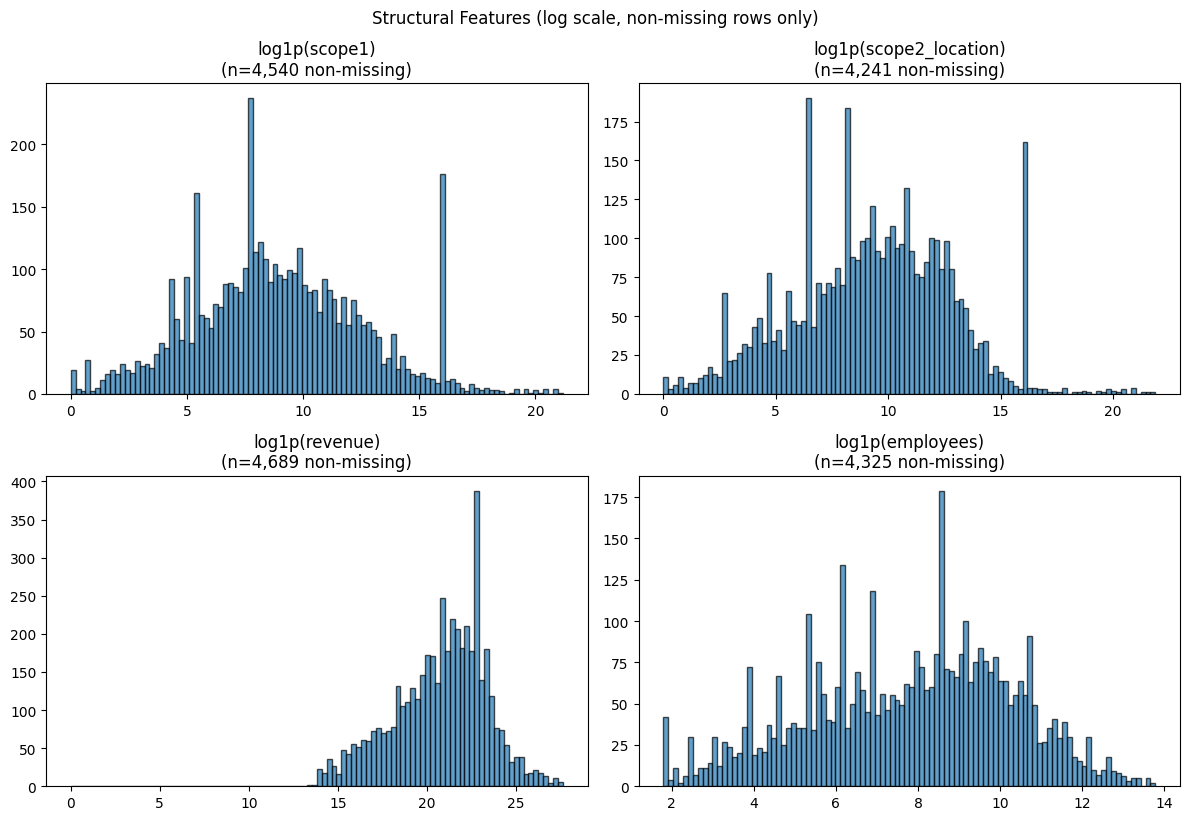

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flat, ['scope1', 'scope2_location', 'revenue', 'employees']):
    if col in df.columns:
        vals = df[col].dropna()
        if len(vals):
            ax.hist(
                np.log1p(np.maximum(vals.astype(float).to_numpy(), 0)),
                bins=100, edgecolor='black', alpha=0.7
            )
        ax.set_title(f'log1p({col})\n(n={len(vals):,} non-missing)')
plt.tight_layout()
plt.suptitle('Structural Features (log scale, non-missing rows only)', y=1.02)
plt.show()

* After applying log transformation, the distributions become much more balanced and less skewed. 
* Most features now show a roughly normal shape, which indicates that the preprocessing steps were effective.

#### 4.3 Commitment Features (Targets & Initiatives)

**What we will do:** Explore binary/count features like near-term targets, net-zero commitment, Race to Zero, RE100, EV100.

In [18]:
commitment_cols = ['has_near_term_target', 'ambition_level_nearterm', 'ambition_level_longterm', 'race_to_zero', 'RE100', 'EV100']
print("Commitment features - value counts:")
for col in commitment_cols:
    if col in df.columns:
        print(f"\n{col}:")
        print(df[col].value_counts(dropna=False))

Commitment features - value counts:

has_near_term_target:
has_near_term_target
1.0    3506
0.0    1102
NaN     151
Name: count, dtype: int64

ambition_level_nearterm:
ambition_level_nearterm
3.0    3319
0.0    1102
2.0     169
NaN     151
1.0      18
Name: count, dtype: int64

ambition_level_longterm:
ambition_level_longterm
0.0    3509
3.0    1099
NaN     151
Name: count, dtype: int64

race_to_zero:
race_to_zero
0    3104
1    1655
Name: count, dtype: int64

RE100:
RE100
0    4527
1     232
Name: count, dtype: int64

EV100:
EV100
0    4708
1      51
Name: count, dtype: int64



- **has_near_term_target:** Most companies (3506) have a near-term target; 1102 do not.  
- **race_to_zero:** About one-third joined Race to Zero ; they may be more likely to join TCP.  
- **RE100 / EV100:** Very few joined (232 and 51). These are niche initiatives but might signal high commitment.  
- **Takeaway:** Companies with more climate commitments could be better TCP outreach targets.

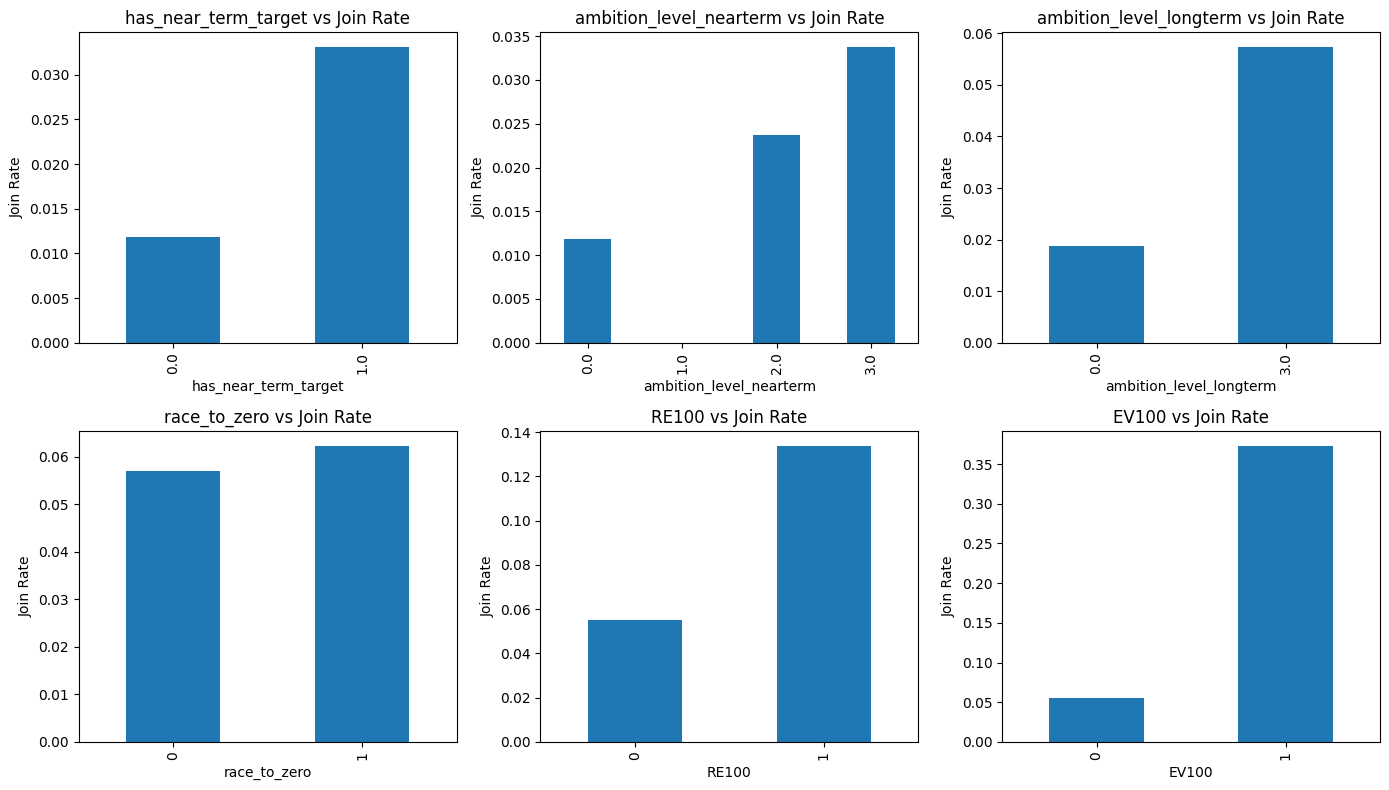

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flat, commitment_cols):
    if col in df.columns:
        df.groupby(col)[TARGET_COL].mean().plot(kind='bar', ax=ax)
        ax.set_title(f'{col} vs Join Rate')
        ax.set_ylabel('Join Rate')
plt.tight_layout()
plt.show()

  
- **Each bar = average join rate** for that category. Higher bars = people in that group join TCP more often.  
- **Example:** If "race_to_zero = 1" has a higher bar than "race_to_zero = 0", companies in Race to Zero are more likely to join TCP.  
- **Takeaway:** Features where bars differ a lot between groups are good predictors; they help the model tell joiners from non-joiners.

#### 4.4 Disclosure Features

**What we will do:** Look at disclosure-related columns (e.g., CDP participation, scope reporting).

In [20]:
disclosure_cols = ['in_cdp', 'missing_s1s2_near_abs_pct', 'missing_s3_near_abs_pct', 'scope3_category_count_near', 'change_pct_s1s2']
print("Disclosure features - missing %:")
for col in disclosure_cols:
    if col in df.columns:
        miss = df[col].isna().mean() * 100
        print(f"  {col}: {miss:.2f}%")

Disclosure features - missing %:
  in_cdp: 0.00%
  missing_s1s2_near_abs_pct: 3.17%
  missing_s3_near_abs_pct: 3.17%
  scope3_category_count_near: 3.17%
  change_pct_s1s2: 62.37%


#### 4.5 Categorical: Region, Sector, Organization Type

**What we will do:** Inspect region, sector, and organization type. These will be one-hot encoded later for the model.

In [21]:
# X_train_cv, X_val created in Section 6 (with train_test_split) — keeps features consistent

In [22]:
print("organization_type:", df['organization_type'].value_counts().to_dict())
print("\nTop regions:", df['region'].value_counts().head(10).to_dict())
print("\nTop sectors:", df['sector'].value_counts().head(8).to_dict())

organization_type: {'Corporate': 3402, 'SME': 1198, 'Financial Institution': 155, 'Company': 4}

Top regions: {'Europe': 2231, 'Asia': 1464, 'Northern America': 768, 'Oceania': 74, 'Latin America and the Caribbean': 72, 'EUROPE': 61, 'Africa': 36, 'AMER': 35, 'MENA': 9, 'LATAM': 4}

Top sectors: {'Professional Services': 362, 'Electrical Equipment and Machinery': 355, 'Software and Services': 342, 'Food and Beverage Processing': 237, 'Construction and Engineering': 235, 'Textiles, Apparel, Footwear and Luxury Goods': 222, 'Real Estate': 200, 'Technology Hardware and Equipment': 190}


## 5. Feature Engineering

#### 5.1 Categorical Feature Cleaning

* This step standardizes messy categorical columns into broader, consistent groups for modeling.

* The `region` column is cleaned into categories such as `Europe`, `Asia-Pacific`, `North America`, `Latin America`, `MENA & Africa`, `Other`, and `Unknown`.

* The `sector` column is also grouped into broader industry categories such as `Energy & Utilities`, `Technology & Electronics`, `Financial Services`, `Retail & Consumer`, and others.



In [23]:
def clean_region(x):
    if pd.isna(x):
        return "Unknown"
    
    x = str(x).lower().strip()

    if any(k in x for k in [
        "europe", "western european","Western European and Others Group (WEOG)"

    ]):
        return "Europe"

    if any(k in x for k in [
        "asia", "apac", "pacific", "oceania", "australia"
    ]):
        return "Asia-Pacific"

    if any(k in x for k in [
        "latin america", "latin america and the caribbean", 
        "latam", "south america", "caribbean"
    ]):
        return "Latin America"

    if any(k in x for k in [
        "africa", "mena", "middle east"
    ]):
        return "MENA & Africa"

    if any(k in x for k in [
        "northern america", "north america", 
        "amer", "americas", "usa", "united states", "canada"
    ]):
        return "North America"

    return "Other"

def clean_sector(x):
    if pd.isna(x):
        return "Unknown"
    x = str(x).lower()
    if any(k in x for k in ['energy','utility','renewable','power','water','waste']): return 'Energy & Utilities'
    if any(k in x for k in ['transport','aviation','air','rail','truck','logistics','marine','port']): return 'Transportation & Logistics'
    if any(k in x for k in ['manufact','chemical','machinery','construction','industrial','building','tire','container']): return 'Manufacturing & Industrial'
    if any(k in x for k in ['tech','software','electronic','semiconductor','data center','media']): return 'Technology & Electronics'
    if any(k in x for k in ['bank','financial','insurance','finance']): return 'Financial Services'
    if any(k in x for k in ['retail','consumer','apparel','textile','fashion','restaurant','beverage']): return 'Retail & Consumer'
    if any(k in x for k in ['food','agricultur','farming']): return 'Food & Agriculture'
    if any(k in x for k in ['real estate','property','infrastructure','homebuilding']): return 'Real Estate & Infrastructure'
    if any(k in x for k in ['health','pharma','biotech']): return 'Healthcare & Pharma'
    if any(k in x for k in ['public','education','service']): return 'Public & Services'
    return 'Other'

df_model = df.copy()
df_model['region_clean'] = df_model['region'].apply(clean_region)
df_model['sector_clean'] = df_model['sector'].apply(clean_sector)
df_model['org_type'] = df_model['organization_type'].fillna('Unknown')
df_model['region_clean'] = df_model['region_clean'].fillna('Unknown')
df_model['sector_clean'] = df_model['sector_clean'].fillna('Unknown')
print("Categorical cleaning done.")

Categorical cleaning done.


* We add missing indicators because missingness itself can carry information.

* For example, if a company does not report scope3, that may say something about its reporting maturity, data availability, or climate commitment level. That pattern could help the model predict whether a company joins TCP.

In [24]:
# Missing indicators (BEFORE imputation)
df_model['scope1_missing'] = df_model['scope1'].isna().astype(int)
df_model['scope2_missing'] = df_model['scope2_location'].isna().astype(int)
df_model['scope3_missing'] = df_model['scope3'].isna().astype(int)
df_model['change_pct_s1s2_missing'] = df_model['change_pct_s1s2'].isna().astype(int)
print("Missing indicators added.")

Missing indicators added.


####  5.2  Imputing `change_pct_s1s2`

* This step fills missing values in `change_pct_s1s2`.

First, the code tries to recalculate the percentage change using available baseline and current Scope 1 + Scope 2 emissions values. If baseline values are missing, older year values are used as fallback sources.


In [25]:
# Impute change_pct_s1s2 from emissions (y4/y3 fallback)
# Fill missing change_pct_s1s2 only when it can be calculated from available emissions data

missing_mask = df_model["change_pct_s1s2"].isna()

baseline_s1s2 = (df_model["baseline_scope1"] + df_model["baseline_scope2"]).replace(0, np.nan)

baseline_s1s2 = baseline_s1s2.fillna(
    (df_model["y4_scope1"] + df_model["y4_scope2_location"]).replace(0, np.nan)
)

baseline_s1s2 = baseline_s1s2.fillna(
    (df_model["y3_scope1"] + df_model["y3_scope2_location"]).replace(0, np.nan)
)

current_s1s2 = df_model["scope1"].add(df_model["scope2_location"])

current_s1s2 = current_s1s2.fillna(
    df_model["y1_scope1"].add(df_model["y1_scope2_location"])
)

current_s1s2 = current_s1s2.fillna(
    df_model["y2_scope1"].add(df_model["y2_scope2_location"])
)

current_s1s2 = current_s1s2.fillna(
    df_model["y3_scope1"].add(df_model["y3_scope2_location"])
)

current_s1s2 = current_s1s2.fillna(
    df_model["y4_scope1"].add(df_model["y4_scope2_location"])
)

valid = baseline_s1s2.notna() & (baseline_s1s2 > 0) & current_s1s2.notna()

change = ((current_s1s2 - baseline_s1s2) / baseline_s1s2) * 100

fillable = missing_mask & valid

df_model.loc[fillable, "change_pct_s1s2"] = change[fillable]

print(f"change_pct_s1s2 filled from emissions data: {int(fillable.sum())}")
print(f"change_pct_s1s2 still missing: {int(df_model['change_pct_s1s2'].isna().sum())}")

change_pct_s1s2 filled from emissions data: 1319
change_pct_s1s2 still missing: 1649


#### 5.3 Derived Feature Creation


* First, Scope 1 and Scope 2 emissions are combined into `s1s2_total`. Then log-transformed features are created for Scope 1+2, Scope 3, revenue, and employees to reduce skewness.

* Using intensity features, such as emissions per revenue and emissions per employee. These features help compare companies of different sizes more fairly.



In [26]:
# Derived features
# Keep missing emissions values as NaN

# Create cleaned revenue and employees columns

df_model["revenue_clean"] = df_model["revenue"]
df_model.loc[df_model["revenue_clean"] <= 0, "revenue_clean"] = np.nan

sector_rev = df_model.groupby("sector_clean")["revenue_clean"].transform("median")
df_model["revenue_clean"] = df_model["revenue_clean"].fillna(sector_rev)
df_model["revenue_clean"] = df_model["revenue_clean"].fillna(df_model["revenue_clean"].median())


df_model["employees_clean"] = df_model["employees"]
df_model.loc[df_model["employees_clean"] <= 0, "employees_clean"] = np.nan

sector_emp = df_model.groupby("sector_clean")["employees_clean"].transform("median")
df_model["employees_clean"] = df_model["employees_clean"].fillna(sector_emp)
df_model["employees_clean"] = df_model["employees_clean"].fillna(df_model["employees_clean"].median())

print("revenue_clean and employees_clean created.")


df_model["s1s2_total"] = df_model["scope1"] + df_model["scope2_location"]

# Log features
df_model["log_s1s2"] = np.log1p(np.maximum(df_model["s1s2_total"], 0))
df_model["log_scope3"] = np.log1p(np.maximum(df_model["scope3"], 0))
df_model["log_revenue"] = np.log1p(df_model["revenue_clean"])
df_model["log_employees"] = np.log1p(df_model["employees_clean"])

# Safe revenue and employee values for division
rev_safe = df_model["revenue_clean"].replace(0, np.nan)
emp_safe = df_model["employees_clean"].replace(0, np.nan)

# Emissions per revenue
df_model["emissions_intensity"] = df_model["s1s2_total"] / rev_safe
df_model["operational_intensity"] = df_model["emissions_intensity"]
df_model["log_operational_intensity"] = np.log1p(df_model["emissions_intensity"])

# Total emissions and emissions per employee
total_emissions = df_model["s1s2_total"] + df_model["scope3"]

df_model["employee_intensity"] = total_emissions / emp_safe
df_model["log_total_intensity"] = np.log1p(total_emissions / rev_safe)

print("Derived features created. Missing emissions values are kept as NaN.")

revenue_clean and employees_clean created.
Derived features created. Missing emissions values are kept as NaN.


## 6. Model Training and Evaluation

#### 6.1 Preparing Final Feature Set
We combine all engineered features into one list (structural + commitment + disclosure + encoded region/sector/org). Then we remove any columns that don't exist and build our X (features) and y (target) for modeling.


In [27]:
# Define feature groups
STRUCTURAL = [
    'log_s1s2', 'log_scope3', 'log_revenue', 'log_employees',
    'log_operational_intensity', 'log_total_intensity',
    'scope1_missing', 'scope2_missing', 'scope3_missing'
]

COMMITMENT = [
    'has_near_term_target', 'ambition_level_nearterm',
    'ambition_level_longterm', 'race_to_zero', 'RE100', 'EV100'
]

DISCLOSURE = [
    'in_cdp', 'missing_s1s2_near_abs_pct',
    'missing_s3_near_abs_pct', 'scope3_category_count_near',
    'change_pct_s1s2_missing'
]

# Save original labels before one-hot encoding
_region_label = df_model['region_clean'].copy()
_sector_label = df_model['sector_clean'].copy()

# One-hot encode categorical columns
df_enc = pd.get_dummies(
    df_model,
    columns=['region_clean', 'sector_clean', 'org_type'],
    drop_first=True
)

# Clean column names by replacing spaces with underscores
df_enc.columns = [str(c).replace(' ', '_') for c in df_enc.columns]

# Add original labels back for later analysis
df_enc['region_clean'] = _region_label.values
df_enc['sector_clean'] = _sector_label.values

# Collect encoded categorical feature columns
region_cols = [c for c in df_enc.columns if c.startswith('region_clean_')]
sector_cols = [c for c in df_enc.columns if c.startswith('sector_clean_')]
org_cols = [c for c in df_enc.columns if c.startswith('org_type_')]

# Build final feature list
FEATURE_COLS = STRUCTURAL + COMMITMENT + DISCLOSURE + region_cols + sector_cols + org_cols

# Keep only features that exist in the encoded dataframe
FEATURE_COLS = [c for c in FEATURE_COLS if c in df_enc.columns]

# Create model input X and target y
X = df_enc[FEATURE_COLS]
y = df_enc[TARGET_COL]

print(f"Final features: {len(FEATURE_COLS)}")
print(f"X shape: {X.shape}, y shape: {y.shape}")

print("\nFirst 15 features:")
print(FEATURE_COLS[:15])

Final features: 38
X shape: (4759, 38), y shape: (4759,)

First 15 features:
['log_s1s2', 'log_scope3', 'log_revenue', 'log_employees', 'log_operational_intensity', 'log_total_intensity', 'scope1_missing', 'scope2_missing', 'scope3_missing', 'has_near_term_target', 'ambition_level_nearterm', 'ambition_level_longterm', 'race_to_zero', 'RE100', 'EV100']


In [28]:
X.dtypes

log_s1s2                                     float64
log_scope3                                   float64
log_revenue                                  float64
log_employees                                float64
log_operational_intensity                    float64
log_total_intensity                          float64
scope1_missing                                 int64
scope2_missing                                 int64
scope3_missing                                 int64
has_near_term_target                         float64
ambition_level_nearterm                      float64
ambition_level_longterm                      float64
race_to_zero                                   int64
RE100                                          int64
EV100                                          int64
in_cdp                                         int64
missing_s1s2_near_abs_pct                    float64
missing_s3_near_abs_pct                      float64
scope3_category_count_near                   f

#### 6.2 Split modeling into 3 stages

Model workflow has three separate stages:

**Stage A: model development**

Train and tune on a training set

**Stage B: model evaluation**

Compare baseline XGboost vs PU bagging on held-out positives / validation data

**Stage C: final production scoring**

Retrain the best model on all data, then score all non-TCP companies

#### StageA: Model development

* Because many non-TCP companies may actually be future joiners, treating all non-TCP companies as true negatives would be too strong of an assumption. To better reflect the real business setting, a hidden-positive evaluation strategy was used. 
* In this approach, a portion of the known TCP joiners was temporarily hidden from training by relabeling them as unlabeled. The model was then trained on the remaining visible positives together with the unlabeled pool, and evaluated based on whether it could rank these hidden joiners near the top. This setup is more realistic because it mimics the real-world task of identifying future joiners from a large pool of companies that have not yet joined.

* **split and holdout set:**  
1. The data was split at the company level so that the same company did not appear in both training and evaluation.
2. From the known TCP joiners, 20% were selected as hidden positives for evaluation.
3. These hidden positives were temporarily relabeled as unlabeled during training.
4. The remaining known TCP joiners were kept labeled as positive in the training data.
5. All non-TCP companies remained unlabeled in the training data.
6. A baseline XGBoost model was trained by treating the visible TCP joiners as positive and all unlabeled companies as negative.
7. A PU bagging model was trained by keeping the visible TCP joiners as positive and repeatedly sampling from the unlabeled pool as temporary negatives across multiple bags.
8. After training, both models were used to score all companies.
9. The hidden positives were used only for evaluation by checking whether they were ranked near the top by each model.
10. The two models were compared using ranking-based metrics, including Recall@50, Recall@100, Precision@100, and PR-AUC.
11. This process was repeated across multiple random seeds, and the results were averaged to obtain a more reliable estimate of model performance.

#### step1: imports

In [29]:
from xgboost import XGBClassifier
from sklearn.metrics import average_precision_score
from sklearn.base import clone


#### step2: metrics for evaluation: Recall@K and Precision@K


* We use `recall_at_k` and `precision_at_k` to evaluate how well the model ranks the most promising companies near the top of the list.

* Since the goal is not only to classify companies, but also to identify the best TCP prospects, ranking metrics are useful. `Recall@K` shows how many hidden TCP joiners appear in the top K predicted companies, while `Precision@K` shows how many of the top K predictions are actual positives.

* This is important because in a real outreach setting, we may only contact the top 50 or top 100 companies. These metrics help measure whether the model is placing the most relevant companies near the top.

* Hidden positives are the TCP companies we hide from training.

* After scoring all companies, we check whether those hidden positives appear near the top.

In [30]:
def recall_at_k(hidden_positive, scores, k):
    topk_idx = np.argsort(-scores)[:k]
    return hidden_positive[topk_idx].sum() / max(hidden_positive.sum(), 1)

def precision_at_k(y_true, scores, k):
    topk_idx = np.argsort(-scores)[:k]
    return y_true[topk_idx].sum() / k


#### Step 3: PU bagging

* `fit_pu_bagging_models` trains one XGBoost per bag (all visible positives + a random unlabeled subsample). `pu_bagging_predict_proba` averages bagged `predict_proba` outputs.

In [31]:
from sklearn.base import clone

# Train multiple PU bagging models
def fit_pu_bagging_models(X, y, base_model, n_bags=50, unlabeled_ratio=1.0, random_state=42):

    # Reset index so row positions are clean
    X = pd.DataFrame(X).reset_index(drop=True)
    y = pd.Series(y).reset_index(drop=True)

    # Separate known positives and unlabeled rows
    pos_idx = np.where(y == 1)[0]
    unlabeled_idx = np.where(y == 0)[0]

    # Number of unlabeled rows to sample in each bag
    n_pos = len(pos_idx)
    n_unlabeled = min(len(unlabeled_idx), int(n_pos * unlabeled_ratio))

    rng = np.random.RandomState(random_state)
    models = []

    # Train many models using all positives + sampled unlabeled rows
    for i in range(n_bags):
        sampled_unlabeled = rng.choice(unlabeled_idx, size=n_unlabeled, replace=False)

        train_idx = np.concatenate([pos_idx, sampled_unlabeled])

        model = clone(base_model)
        model.set_params(random_state=random_state + i)

        model.fit(X.iloc[train_idx], y.iloc[train_idx])

        models.append(model)

    return models


# Predict by averaging probabilities from all bagging models
def pu_bagging_predict_proba(models, X):

    X = pd.DataFrame(X).reset_index(drop=True)

    probs = []

    for model in models:
        probs.append(model.predict_proba(X)[:, 1])

    avg_prob = np.mean(probs, axis=0)

    return np.column_stack([1 - avg_prob, avg_prob])

#### Step 4: hidden-positive split function

This hides 20% of TCP companies by relabeling them as 0 during training.

In [32]:
# Hide some known TCP joiners to test if the model can rediscover them
def make_hidden_positive_split(df, target_col, hide_frac=0.20, random_state=42):

    # Copy data and reset index
    df = df.copy().reset_index(drop=True)

    # Get row indexes where target is positive
    positive_idx = df.index[df[target_col] == 1].to_numpy()

    # Randomly choose some positives to hide
    rng = np.random.RandomState(random_state)
    n_hide = max(1, int(len(positive_idx) * hide_frac))

    hidden_pos_idx = rng.choice(
        positive_idx,
        size=n_hide,
        replace=False
    )

    # Create training labels
    # Hidden positives are changed from 1 to 0 during training
    train_labels = df[target_col].copy()
    train_labels.iloc[hidden_pos_idx] = 0

    # Keep a separate mask to remember which rows were hidden positives
    hidden_positive_mask = np.zeros(len(df), dtype=int)
    hidden_positive_mask[hidden_pos_idx] = 1

    return train_labels, hidden_positive_mask, hidden_pos_idx

In [33]:
train_labels_demo, hidden_demo, _ = make_hidden_positive_split(
    df_enc, TARGET_COL, hide_frac=0.20, random_state=42
)

orig_pos = (df_enc[TARGET_COL] == 1).sum()
orig_neg = (df_enc[TARGET_COL] == 0).sum()
visible_pos = (train_labels_demo == 1).sum()
hidden_pos = hidden_demo.sum()
unlabeled_pool = (train_labels_demo == 0).sum()

print("Hidden-positive split example")
print(f"Original TCP joiners: {orig_pos}")
print(f"Original non-joiners: {orig_neg}")
print(f"Visible positives in training: {visible_pos}")
print(f"Hidden positives: {hidden_pos}")
print(f"Unlabeled pool for training: {unlabeled_pool}")

Hidden-positive split example
Original TCP joiners: 280
Original non-joiners: 4479
Visible positives in training: 224
Hidden positives: 56
Unlabeled pool for training: 4535


#### Step 5: one evaluation run
#### Baseline XGBoost Hidden-Positive Evaluation

* `train_baseline_xgb_hidden_eval` trains a regular XGBoost binary classifier using the modified training labels, where some known TCP joiners have been hidden as `0`.

* It calculates `scale_pos_weight` to handle class imbalance because there are usually many more non-joiners than joiners. After training, it returns the model and the predicted probability score for each row.

#### PU Bagging Hidden-Positive Evaluation

* `train_pu_bagging_hidden_eval` trains a Positive-Unlabeled bagging model. It uses all known positives and repeatedly samples from the unlabeled group to train many XGBoost models.

* The final score is the average predicted probability across all bagged models. This helps reduce bias because many rows labeled `0` may actually be unknown future TCP joiners.

* Baseline XGB = one normal XGBoost model ,PU Bagging = many XGBoost models trained on positives + sampled unlabeled rows,
Both return scores used to check whether hidden TCP joiners rank near the top

**5a. Baseline XGBoost:**

In [34]:
def train_baseline_xgb_hidden_eval(X, train_labels, seed=42):
    pos_count = (train_labels == 1).sum()
    neg_count = (train_labels == 0).sum()
    scale_pos_weight = neg_count / max(pos_count, 1)

    model = XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight,
        random_state=seed
    )

    model.fit(X, train_labels)
    scores = model.predict_proba(X)[:, 1]

    return model, scores

**5b. PU bagging:**

In [35]:
# Train PU bagging model and return scores
def train_pu_bagging_hidden_eval(X, train_labels, n_bags=50, unlabeled_ratio=1.0, seed=42):

    # Base XGBoost model used in each bag
    pu_base = XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=seed,
    )

    # Train multiple models using all visible positives
    # and a random sample of unlabeled rows each time
    models = fit_pu_bagging_models(
        X,
        train_labels,
        pu_base,
        n_bags=n_bags,
        unlabeled_ratio=unlabeled_ratio,
        random_state=seed,
    )

    # Average predictions from all PU models
    scores = pu_bagging_predict_proba(models, X)[:, 1]

    return models, scores

In [36]:
# Run one hidden-positive experiment

seed = 42
hide_frac = 0.20
n_bags = 50

# Prepare data
df_demo = df_enc.reset_index(drop=True)
X_demo = df_demo[FEATURE_COLS]

# Hide 20% of known TCP joiners by changing their label to 0
y_train, hidden_mask, _ = make_hidden_positive_split(
    df_demo, TARGET_COL, hide_frac=hide_frac, random_state=seed
)

# Train baseline XGBoost model
baseline_model, baseline_scores = train_baseline_xgb_hidden_eval(
    X_demo, y_train, seed=seed
)

# Train PU bagging model
pu_models, pu_scores = train_pu_bagging_hidden_eval(
    X_demo, y_train, n_bags=n_bags, unlabeled_ratio=1.0, seed=seed
)

# Print experiment summary
print("Hidden-positive training example")
print("Visible positives:", (y_train == 1).sum())
print("Hidden positives:", hidden_mask.sum())
print("Unlabeled pool:", (y_train == 0).sum())
print("PU models:", len(pu_models))

Hidden-positive training example
Visible positives: 224
Hidden positives: 56
Unlabeled pool: 4535
PU models: 50


#### step6 : Comparing PUBagging vs. XGBoost


In [37]:
from matplotlib.colors import ListedColormap, BoundaryNorm
import numpy as np

# Colors for the 5 score buckets
bucket_colors = {
    0: "#482878",  # 0–20%
    1: "#3e4989",  # 20–40%
    2: "#26828e",  # 40–60%
    3: "#35b779",  # 60–80%
    4: "#6ece58"   # 80–100%
}

# Create color map for plotting buckets
cmap_b = ListedColormap(list(bucket_colors.values()))
norm_b = BoundaryNorm(np.arange(6), cmap_b.N)

# Convert probability scores into 5 buckets
def score_to_bucket(scores):
    buckets = np.floor(scores * 5).astype(int)
    buckets = np.clip(buckets, 0, 4)
    return buckets

#### 6a.  Propensity score distribution

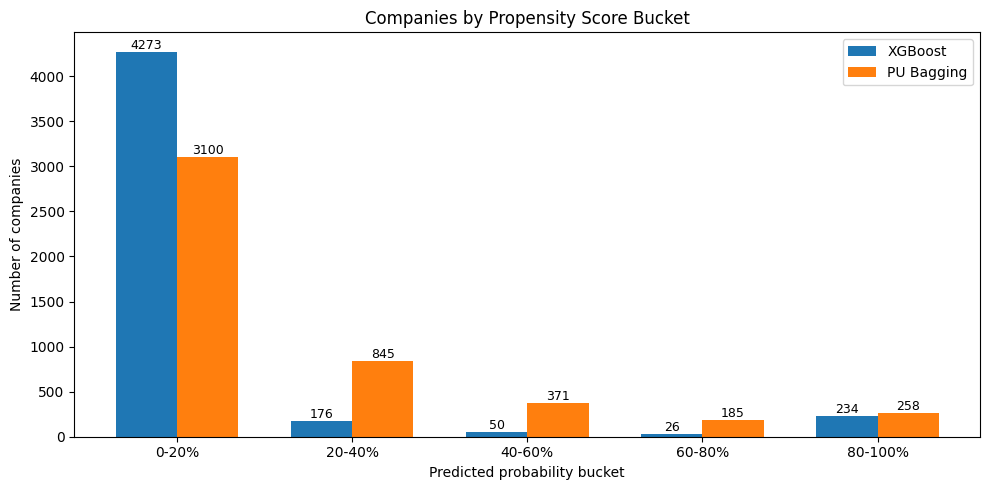

In [38]:
import numpy as np
import matplotlib.pyplot as plt

# Convert probability scores into 5 score buckets
def score_to_bucket(scores):
    scores = np.asarray(scores)
    return np.clip((scores * 5).astype(int), 0, 4)

# Convert model scores to arrays
xgb_scores = np.asarray(baseline_scores)
pu_scores = np.asarray(pu_scores)

# Bucket labels
labels = ["0-20%", "20-40%", "40-60%", "60-80%", "80-100%"]

# Count companies in each bucket for both models
xgb_counts = [(score_to_bucket(xgb_scores) == i).sum() for i in range(5)]
pu_counts = [(score_to_bucket(pu_scores) == i).sum() for i in range(5)]

# Plot side-by-side bars
x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(10, 5))

bars1 = plt.bar(x - width / 2, xgb_counts, width, label="XGBoost")
bars2 = plt.bar(x + width / 2, pu_counts, width, label="PU Bagging")

plt.xticks(x, labels)
plt.xlabel("Predicted probability bucket")
plt.ylabel("Number of companies")
plt.title("Companies by Propensity Score Bucket")
plt.legend()

# Add count labels above bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            str(int(height)),
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout()
plt.show()

* The PU Bagging model distributes companies more evenly across probability buckets, while XGBoost places most companies in the lowest bucket. This suggests that PU Bagging is better at identifying potential hidden positives and provides a more balanced ranking of companies based on their likelihood to join TCP.

#### 6b. PCA Visualization of High-Propensity Companies

* This plot compares the baseline XGBoost model with the proposed PU Bagging model using a 2D PCA visualization.

* First, the model features are standardized and reduced into two PCA components so the companies can be shown on a simple scatter plot. Only companies with a predicted probability of at least 80% are displayed.

* The purpose of this plot is to see which model identifies more high-propensity prospects and how well each model recovers the hidden TCP joiners that were intentionally masked during evaluation. Gold borders represent hidden TCP members that the model successfully recovered.

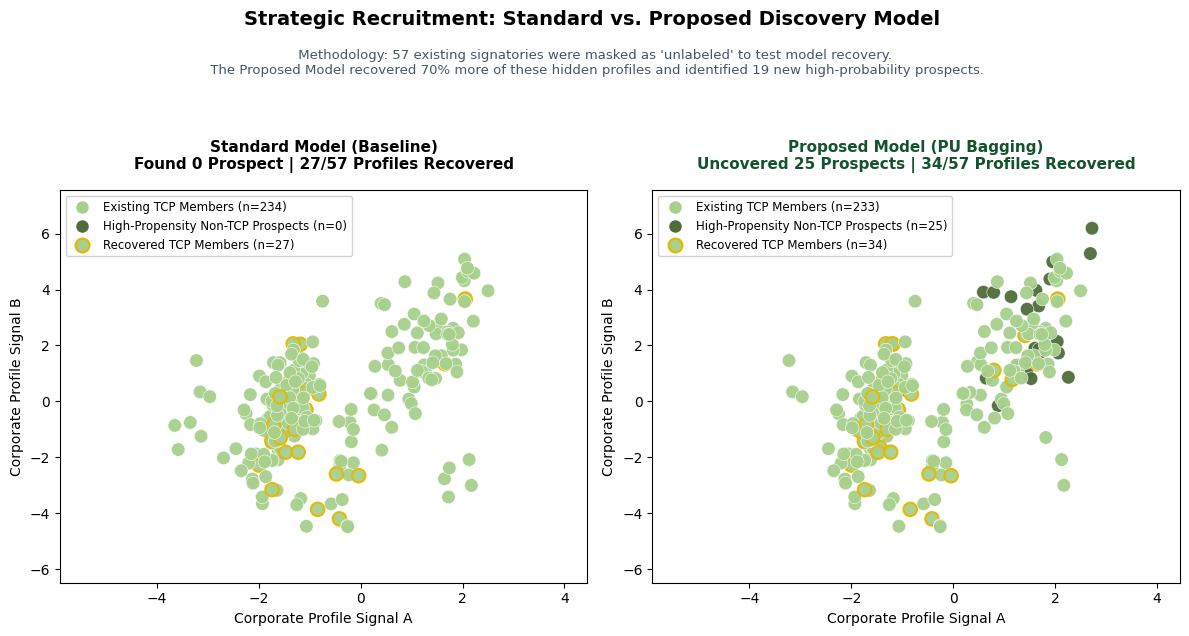

In [39]:
# Standardize features, then reduce them to 2 PCA components
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_demo[FEATURE_COLS].fillna(0))

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Convert model scores and labels to arrays
xgb_scores = np.asarray(baseline_scores)
pu_scores = np.asarray(pu_scores)
y_true = df_demo[TARGET_COL].to_numpy()
hidden_mask = np.asarray(hidden_mask).astype(bool)

# Only show companies with score >= 80%
n_hidden = hidden_mask.sum()
cutoff = 0.80

# Add padding around PCA plot area
x_pad = 0.12 * (X_pca[:, 0].max() - X_pca[:, 0].min() + 1e-9)
y_pad = 0.12 * (X_pca[:, 1].max() - X_pca[:, 1].min() + 1e-9)

x_min, x_max = X_pca[:, 0].min() - x_pad, X_pca[:, 0].max() + x_pad
y_min, y_max = X_pca[:, 1].min() - y_pad, X_pca[:, 1].max() + y_pad

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Main title
fig.text(
    0.5, 1.01,
    "Strategic Recruitment: Standard vs. Proposed Discovery Model \n",
    ha="center", fontsize=14, fontweight="bold", transform=fig.transFigure
)

# Subtitle explaining the experiment
_subtitle = (
    "\n"
    "\n Methodology: 57 existing signatories were masked as 'unlabeled' to test model recovery. \n "
    "The Proposed Model recovered 70% more of these hidden profiles and identified 19 new high-probability prospects."
)

fig.text(
    0.5, 0.965, _subtitle,
    ha="center", fontsize=9.5, color="#475569", transform=fig.transFigure
)

# Plot baseline and PU model results
for ax, scores, is_proposed in [(axes[0], xgb_scores, False), (axes[1], pu_scores, True)]:

    # Keep only high-propensity companies
    idx = np.where(scores >= cutoff)[0]

    X_plot = X_pca[idx]
    y_plot = y_true[idx]
    h_plot = hidden_mask[idx]

    # Color points by actual TCP status
    colors = np.where(y_plot == 1, "#A8D08D", "#4F6D3A")

    # Gold outline shows hidden TCP members recovered by the model
    edges = np.where(h_plot, "#e6b800", "white")
    widths = np.where(h_plot, 1.5, 0.4)

    ax.scatter(
        X_plot[:, 0],
        X_plot[:, 1],
        c=colors,
        s=95,
        edgecolors=edges,
        linewidths=widths,
        alpha=0.95
    )

    # Count groups shown in the plot
    tcp_n = (y_plot == 1).sum()
    prospect_n = (y_plot == 0).sum()
    hidden_n = h_plot.sum()

    # Set model-specific title
    if not is_proposed:
        ax.set_title(
            f"Standard Model (Baseline)\nFound {prospect_n} Prospect | {hidden_n}/57 Profiles Recovered",
            fontsize=11,
            fontweight="bold",
            pad=15
        )
    else:
        ax.set_title(
            f"Proposed Model (PU Bagging)\nUncovered {prospect_n} Prospects | {hidden_n}/57 Profiles Recovered",
            fontsize=11,
            fontweight="bold",
            pad=15,
            color="#14532d"
        )

    # Axis formatting
    ax.set_xlabel("Corporate Profile Signal A")
    ax.set_ylabel("Corporate Profile Signal B")
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.grid(False)

    # Legend
    legend_items = [
        plt.Line2D(
            [0], [0],
            marker="o",
            color="w",
            markerfacecolor="#A8D08D",
            markersize=10,
            label=f"Existing TCP Members (n={tcp_n})"
        ),
        plt.Line2D(
            [0], [0],
            marker="o",
            color="w",
            markerfacecolor="#4F6D3A",
            markersize=10,
            label=f"High-Propensity Non-TCP Prospects (n={prospect_n})"
        ),
        plt.Line2D(
            [0], [0],
            marker="o",
            color="w",
            markerfacecolor="#A8D08D",
            markeredgecolor="#e6b800",
            markeredgewidth=1.5,
            markersize=10,
            label=f"Recovered TCP Members (n={hidden_n})"
        ),
    ]

    ax.legend(handles=legend_items, loc="upper left", fontsize=8.5, framealpha=0.9)

plt.tight_layout(rect=[0, 0.02, 1, 0.88])
plt.show()

* The plots show companies with predicted probability (propensity score) above 80% from both models.
* The PU Bagging model recovers more hidden TCP members and also identifies new high-probability prospects, while the baseline model finds almost none.
* This indicates that PU Bagging is more effective for real-world scenarios where some true positives are hidden or unlabeled.

#### 6c.Hidden-Positive Evaluation Using Recall@K and Precision@K

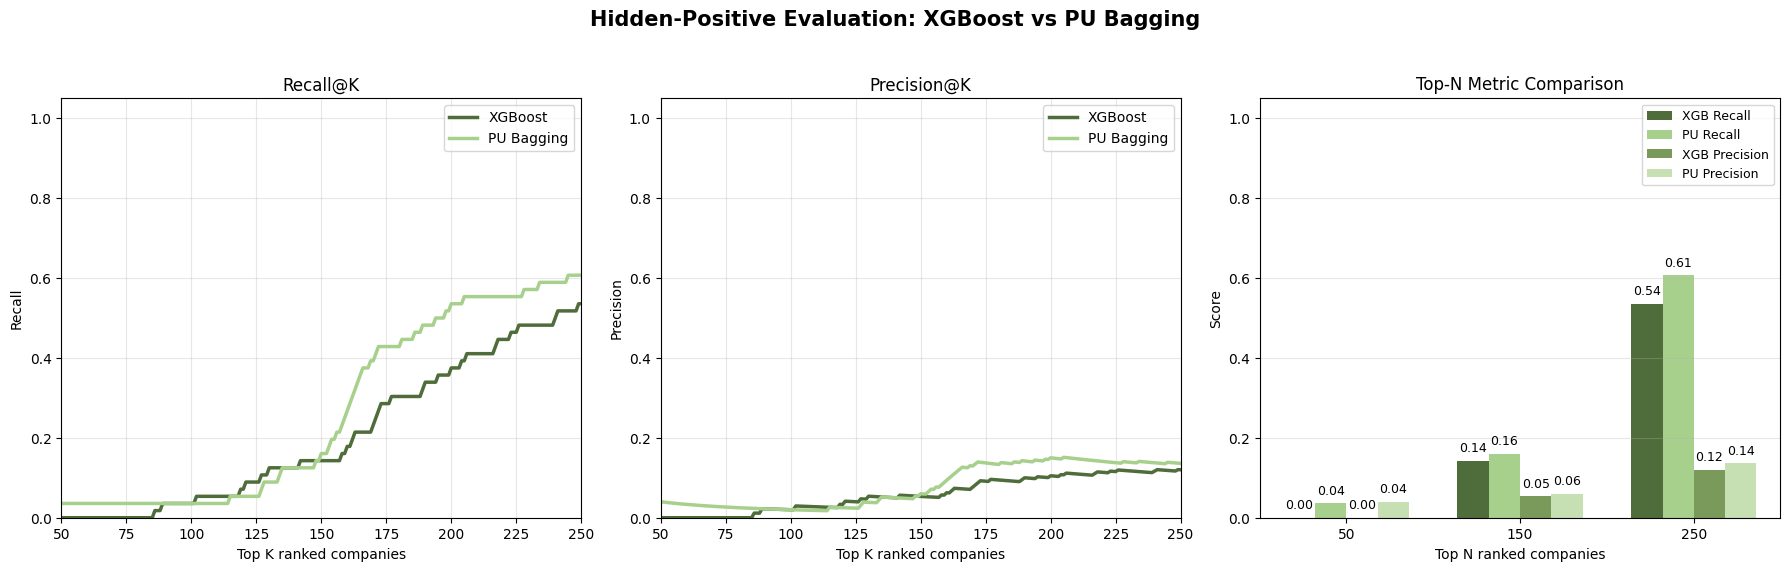

In [40]:
import numpy as np
import matplotlib.pyplot as plt

# Hidden positives are used as the evaluation target
y_eval = np.asarray(hidden_mask).astype(int)

# Convert model scores to arrays
xgb_scores = np.asarray(baseline_scores, dtype=float)
pu_scores_arr = np.asarray(pu_scores, dtype=float)

# Color scheme
dark_green = "#4F6D3A"
light_green = "#A8D08D"
mid_green = "#7A9A5C"
pale_green = "#C6E0B4"


# Calculate Recall@K and Precision@K curves
def recall_precision_at_k(scores, y_true, min_k=100, max_k=300):
    order = np.argsort(-scores)
    y_sorted = y_true[order]

    total_pos = max(y_sorted.sum(), 1)
    tp_cum = np.cumsum(y_sorted)

    k = np.arange(min_k, min(max_k, len(y_sorted)) + 1)

    recall_k = tp_cum[k - 1] / total_pos
    precision_k = tp_cum[k - 1] / k

    return k, recall_k, precision_k


# Recall at one specific K
def recall_at_k(scores, y_true, k):
    order = np.argsort(-scores)[:k]
    return y_true[order].sum() / max(y_true.sum(), 1)


# Precision at one specific K
def precision_at_k(scores, y_true, k):
    order = np.argsort(-scores)[:k]
    return y_true[order].sum() / k


# Evaluation range
min_k = 50
max_k = 250
k_vals = [50, 150, 250]


# Create Recall@K and Precision@K curves
k_xgb, recall_xgb, precision_xgb = recall_precision_at_k(
    xgb_scores, y_eval, min_k=min_k, max_k=max_k
)

k_pu, recall_pu, precision_pu = recall_precision_at_k(
    pu_scores_arr, y_eval, min_k=min_k, max_k=max_k
)


# Calculate metrics at selected top-N values
xgb_recall_topn = [recall_at_k(xgb_scores, y_eval, k) for k in k_vals]
pu_recall_topn = [recall_at_k(pu_scores_arr, y_eval, k) for k in k_vals]

xgb_precision_topn = [precision_at_k(xgb_scores, y_eval, k) for k in k_vals]
pu_precision_topn = [precision_at_k(pu_scores_arr, y_eval, k) for k in k_vals]


# Create plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

fig.suptitle(
    "Hidden-Positive Evaluation: XGBoost vs PU Bagging",
    fontsize=15,
    fontweight="bold",
    y=1.03
)


# Plot 1: Recall@K
axes[0].plot(k_xgb, recall_xgb, label="XGBoost", color=dark_green, linewidth=2.5)
axes[0].plot(k_pu, recall_pu, label="PU Bagging", color=light_green, linewidth=2.5)

axes[0].set_title("Recall@K")
axes[0].set_xlabel("Top K ranked companies")
axes[0].set_ylabel("Recall")
axes[0].set_xlim(min_k, max_k)
axes[0].set_ylim(0, 1.05)
axes[0].grid(alpha=0.3)
axes[0].legend()


# Plot 2: Precision@K
axes[1].plot(k_xgb, precision_xgb, label="XGBoost", color=dark_green, linewidth=2.5)
axes[1].plot(k_pu, precision_pu, label="PU Bagging", color=light_green, linewidth=2.5)

axes[1].set_title("Precision@K")
axes[1].set_xlabel("Top K ranked companies")
axes[1].set_ylabel("Precision")
axes[1].set_xlim(min_k, max_k)
axes[1].set_ylim(0, 1.05)
axes[1].grid(alpha=0.3)
axes[1].legend()


# Plot 3: Top-N bar chart
x = np.arange(len(k_vals))
width = 0.18

bars1 = axes[2].bar(x - 1.5 * width, xgb_recall_topn, width, label="XGB Recall", color=dark_green)
bars2 = axes[2].bar(x - 0.5 * width, pu_recall_topn, width, label="PU Recall", color=light_green)
bars3 = axes[2].bar(x + 0.5 * width, xgb_precision_topn, width, label="XGB Precision", color=mid_green)
bars4 = axes[2].bar(x + 1.5 * width, pu_precision_topn, width, label="PU Precision", color=pale_green)

axes[2].set_title("Top-N Metric Comparison")
axes[2].set_xlabel("Top N ranked companies")
axes[2].set_ylabel("Score")
axes[2].set_xticks(x)
axes[2].set_xticklabels([str(k) for k in k_vals])
axes[2].set_ylim(0, 1.05)
axes[2].grid(axis="y", alpha=0.3)
axes[2].legend(fontsize=9)


# Add score labels above bars
for bars in [bars1, bars2, bars3, bars4]:
    for bar in bars:
        h = bar.get_height()
        axes[2].text(
            bar.get_x() + bar.get_width() / 2,
            h + 0.015,
            f"{h:.2f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout()
plt.show()

* XGBoost struggles especially in the lower Top-K range because it is more conservative and ranks fewer hidden TCP members near the very top. 
* In the early shortlist, such as the top 50 to 150 companies, XGBoost has very low recall and precision, meaning it is missing many hidden positives that should ideally appear earlier. 
* This happens because the baseline model treats all unlabeled companies as true non-joiners, so it becomes biased toward predicting lower scores. 
* In contrast, PU Bagging handles the unlabeled group more carefully and is better at moving likely hidden positives higher in the ranking.

### Step7: Fine Tuning PU model

#### 7a: tune PU bagging using hidden-positive evaluation

In [41]:
# PU Bagging grid search using multiple hidden-positive splits

def evaluate_one_pu_setting(df, feature_cols, target_col, params, seeds, hide_frac=0.20):
    X = df[feature_cols].reset_index(drop=True)

    rows = []

    for seed in seeds:
        # Hide some known TCP joiners for evaluation
        train_labels, hidden_mask, _ = make_hidden_positive_split(
            df, target_col, hide_frac=hide_frac, random_state=seed
        )

        # Base XGBoost model for PU bagging
        base_model = XGBClassifier(
            n_estimators=params["n_estimators"],
            max_depth=params["max_depth"],
            learning_rate=params["learning_rate"],
            subsample=params["subsample"],
            colsample_bytree=params["colsample_bytree"],
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=seed
        )

        # Train PU bagging models
        models = fit_pu_bagging_models(
            X=X,
            y=train_labels,
            base_model=base_model,
            n_bags=params["n_bags"],
            unlabeled_ratio=params["unlabeled_ratio"],
            random_state=seed
        )

        # Predict scores
        scores = pu_bagging_predict_proba(models, X)[:, 1]
        y_eval = hidden_mask

        # Store metrics for this seed
        rows.append({
            "seed": seed,
            "recall_at_100": recall_at_k(scores, y_eval, 100),
            "recall_at_200": recall_at_k(scores, y_eval, 200),
            "precision_at_100": precision_at_k(scores, y_eval, 100),
            "precision_at_200": precision_at_k(scores, y_eval, 200),
            "pr_auc": average_precision_score(y_eval, scores)
        })

    metrics_df = pd.DataFrame(rows)

    # Average metrics across seeds
    summary = {
        **params,
        "mean_recall_at_100": metrics_df["recall_at_100"].mean(),
        "mean_recall_at_200": metrics_df["recall_at_200"].mean(),
        "mean_precision_at_100": metrics_df["precision_at_100"].mean(),
        "mean_precision_at_200": metrics_df["precision_at_200"].mean(),
        "mean_pr_auc": metrics_df["pr_auc"].mean(),
        "std_recall_at_100": metrics_df["recall_at_100"].std(),
        "std_recall_at_200": metrics_df["recall_at_200"].std()
    }

    return summary, metrics_df

In [42]:
# Grid search settings

from itertools import product

param_grid = {
    "n_estimators": [200, 300],
    "max_depth": [3, 4],
    "learning_rate": [0.03, 0.05],
    "subsample": [0.8],
    "colsample_bytree": [0.8],
    "n_bags": [30, 50],
    "unlabeled_ratio": [1.0, 2.0]
}

seeds = [42, 52, 62, 72, 82]

grid_results = []
grid_details = {}

df_grid = df_enc.reset_index(drop=True)

for values in product(*param_grid.values()):
    params = dict(zip(param_grid.keys(), values))

    print("Testing:", params)

    summary, metrics_df = evaluate_one_pu_setting(
        df=df_grid,
        feature_cols=FEATURE_COLS,
        target_col=TARGET_COL,
        params=params,
        seeds=seeds,
        hide_frac=0.20
    )

    grid_results.append(summary)
    grid_details[str(params)] = metrics_df

results_df = pd.DataFrame(grid_results)

# Rank using both recall and precision
results_df["combined_score"] = (
    0.50 * results_df["mean_recall_at_200"] +
    0.30 * results_df["mean_precision_at_100"] +
    0.20 * results_df["mean_pr_auc"]
)

results_df = results_df.sort_values("combined_score", ascending=False).reset_index(drop=True)

display(results_df.head(10))

Testing: {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.03, 'subsample': 0.8, 'colsample_bytree': 0.8, 'n_bags': 30, 'unlabeled_ratio': 1.0}
Testing: {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.03, 'subsample': 0.8, 'colsample_bytree': 0.8, 'n_bags': 30, 'unlabeled_ratio': 2.0}
Testing: {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.03, 'subsample': 0.8, 'colsample_bytree': 0.8, 'n_bags': 50, 'unlabeled_ratio': 1.0}
Testing: {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.03, 'subsample': 0.8, 'colsample_bytree': 0.8, 'n_bags': 50, 'unlabeled_ratio': 2.0}
Testing: {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'n_bags': 30, 'unlabeled_ratio': 1.0}
Testing: {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'n_bags': 30, 'unlabeled_ratio': 2.0}
Testing: {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05, 'subsample': 0.8, 'colsa

,n_estimators,max_depth,learning_rate,subsample,colsample_bytree,n_bags,unlabeled_ratio,mean_recall_at_100,mean_recall_at_200,mean_precision_at_100,mean_precision_at_200,mean_pr_auc,std_recall_at_100,std_recall_at_200,combined_score
0,200,3,0.03,0.8,0.8,50,1.0,0.225000,0.650000,0.126,0.182,0.122170,0.020360,0.046566,0.387234
1,200,3,0.03,0.8,0.8,30,1.0,0.235714,0.642857,0.132,0.180,0.125709,0.034349,0.053571,0.386170
2,200,3,0.03,0.8,0.8,30,2.0,0.203571,0.653571,0.114,0.183,0.121703,0.051446,0.051446,0.385326
3,200,3,0.03,0.8,0.8,50,2.0,0.182143,0.653571,0.102,0.183,0.120847,0.038713,0.055902,0.381555
4,300,3,0.03,0.8,0.8,30,1.0,0.203571,0.642857,0.114,0.180,0.119332,0.037029,0.055039,0.379495
5,200,3,0.05,0.8,0.8,30,1.0,0.192857,0.642857,0.108,0.180,0.117512,0.034349,0.055039,0.377331
6,300,3,0.03,0.8,0.8,50,1.0,0.175000,0.642857,0.098,0.180,0.115359,0.026486,0.055039,0.373900
7,300,3,0.03,0.8,0.8,30,2.0,0.164286,0.646429,0.092,0.181,0.115249,0.040721,0.052671,0.373864
8,200,4,0.03,0.8,0.8,30,1.0,0.160714,0.642857,0.090,0.180,0.116912,0.025254,0.053571,0.371811
9,200,3,0.05,0.8,0.8,50,1.0,0.164286,0.642857,0.092,0.180,0.113072,0.029342,0.055039,0.371643


In [49]:
# Best PU Bagging setting

best_params = results_df.iloc[0][list(param_grid.keys())].to_dict()

print("Best parameters:")
print(best_params)

print("\nBest result:")
display(results_df.head(1))

Best parameters:
{'n_estimators': 200.0, 'max_depth': 3.0, 'learning_rate': 0.03, 'subsample': 0.8, 'colsample_bytree': 0.8, 'n_bags': 50.0, 'unlabeled_ratio': 1.0}

Best result:


,n_estimators,max_depth,learning_rate,subsample,colsample_bytree,n_bags,unlabeled_ratio,mean_recall_at_100,mean_recall_at_200,mean_precision_at_100,mean_precision_at_200,mean_pr_auc,std_recall_at_100,std_recall_at_200,combined_score
0,200,3,0.03,0.8,0.8,50,1.0,0.225,0.65,0.126,0.182,0.12217,0.02036,0.046566,0.387234


In [50]:
best_config = {
    "n_bags": int(best_params["n_bags"]),
    "unlabeled_ratio": float(best_params["unlabeled_ratio"]),
    "n_estimators": int(best_params["n_estimators"]),
    "max_depth": int(best_params["max_depth"]),
    "learning_rate": float(best_params["learning_rate"]),
    "subsample": float(best_params["subsample"]),
    "colsample_bytree": float(best_params["colsample_bytree"]),
}

#### 7b.Retrain PU bagging on all data

In [51]:
X_all = df_enc[FEATURE_COLS].reset_index(drop=True)
y_all = df_enc[TARGET_COL].reset_index(drop=True)

final_base_model = XGBClassifier(
    n_estimators=best_config["n_estimators"],
    max_depth=best_config["max_depth"],
    learning_rate=best_config["learning_rate"],
    subsample=best_config["subsample"],
    colsample_bytree=best_config["colsample_bytree"],
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

final_pu_models = fit_pu_bagging_models(
    X=X_all,
    y=y_all,
    base_model=final_base_model,
    n_bags=best_config["n_bags"],
    unlabeled_ratio=best_config["unlabeled_ratio"],
    random_state=42
)



### 7c .SHAP feature importance (PU bag)



This step uses SHAP to understand which features most influence the PU Bagging model predictions.

In [52]:
# SHAP global importance and summary plot
# Requires: pip install shap

import shap
from IPython.display import display

# Prepare feature matrix for SHAP
# SHAP needs numeric float values
X_fm = X_all.fillna(0).copy()
X_fm = X_fm.apply(lambda s: pd.to_numeric(s, errors="coerce")).fillna(0.0)
X_fm = X_fm.astype(np.float64)

# Random samples to make SHAP faster
RNG = np.random.default_rng(42)

N_BG = 400      # background sample size
N_EXP = 1500    # explanation sample size

bg_idx = RNG.choice(len(X_fm), size=min(N_BG, len(X_fm)), replace=False)
exp_idx = RNG.choice(len(X_fm), size=min(N_EXP, len(X_fm)), replace=False)

X_bg = X_fm.iloc[bg_idx]
X_exp = X_fm.iloc[exp_idx]

# Explain one model from the PU Bagging model list
model_for_shap = final_pu_models[0]

# Create SHAP explainer
explainer = shap.TreeExplainer(model_for_shap, data=X_bg)

# Calculate SHAP values
sv = explainer.shap_values(X_exp)

# Some SHAP versions return [class 0, class 1]
# For binary classification, use class 1
if isinstance(sv, list):
    sv = sv[1]

# Calculate global feature importance
feat_names = list(FEATURE_COLS)
mean_abs_shap = np.asarray(np.abs(sv)).mean(axis=0)

shap_importance = (
    pd.DataFrame({
        "feature": feat_names,
        "mean_abs_shap": mean_abs_shap
    })
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)

# Display top important features
display(shap_importance.head(25))

,feature,mean_abs_shap
0,change_pct_s1s2_missing,0.540619
1,race_to_zero,0.279283
2,log_s1s2,0.278262
3,log_total_intensity,0.200224
4,in_cdp,0.169188
5,org_type_Corporate,0.169148
6,region_clean_North_America,0.132403
7,scope3_category_count_near,0.123852
8,log_scope3,0.110673
9,ambition_level_nearterm,0.109269


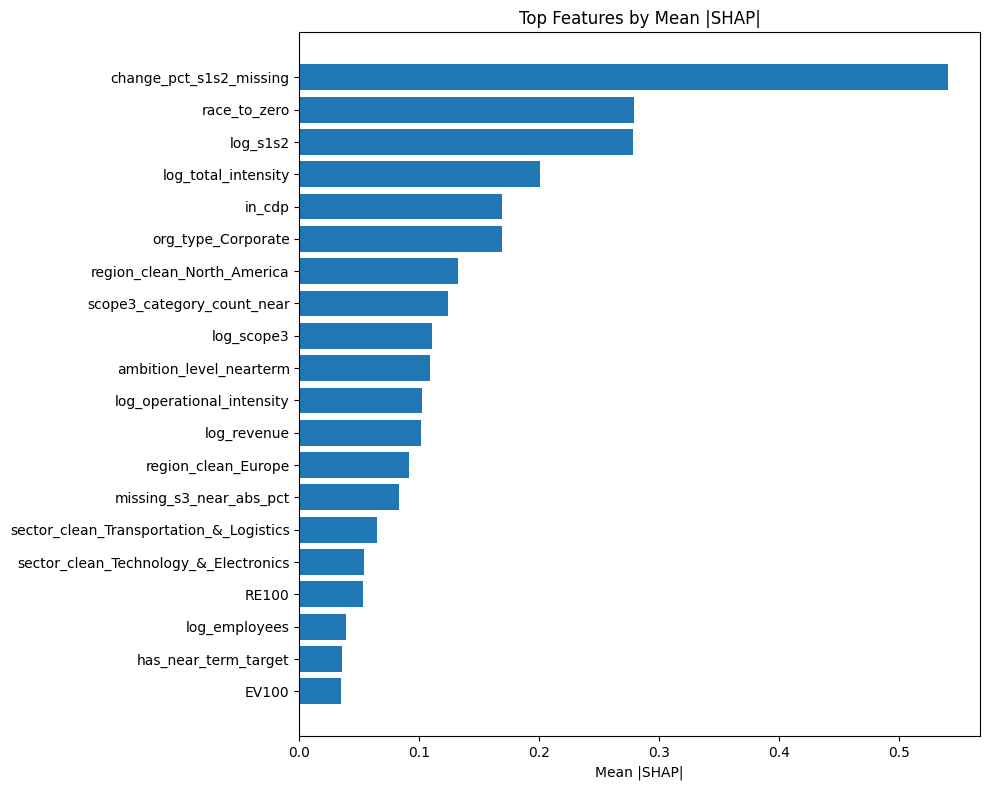

In [53]:
# Bar plot of top SHAP features

top_n = 20

plt.figure(figsize=(10, 8))

plt.barh(
    shap_importance["feature"].head(top_n)[::-1],
    shap_importance["mean_abs_shap"].head(top_n)[::-1]
)

plt.xlabel("Mean |SHAP|")
plt.title("Top Features by Mean |SHAP|")
plt.tight_layout()
plt.show()

### 7d. Plotting top 10 features


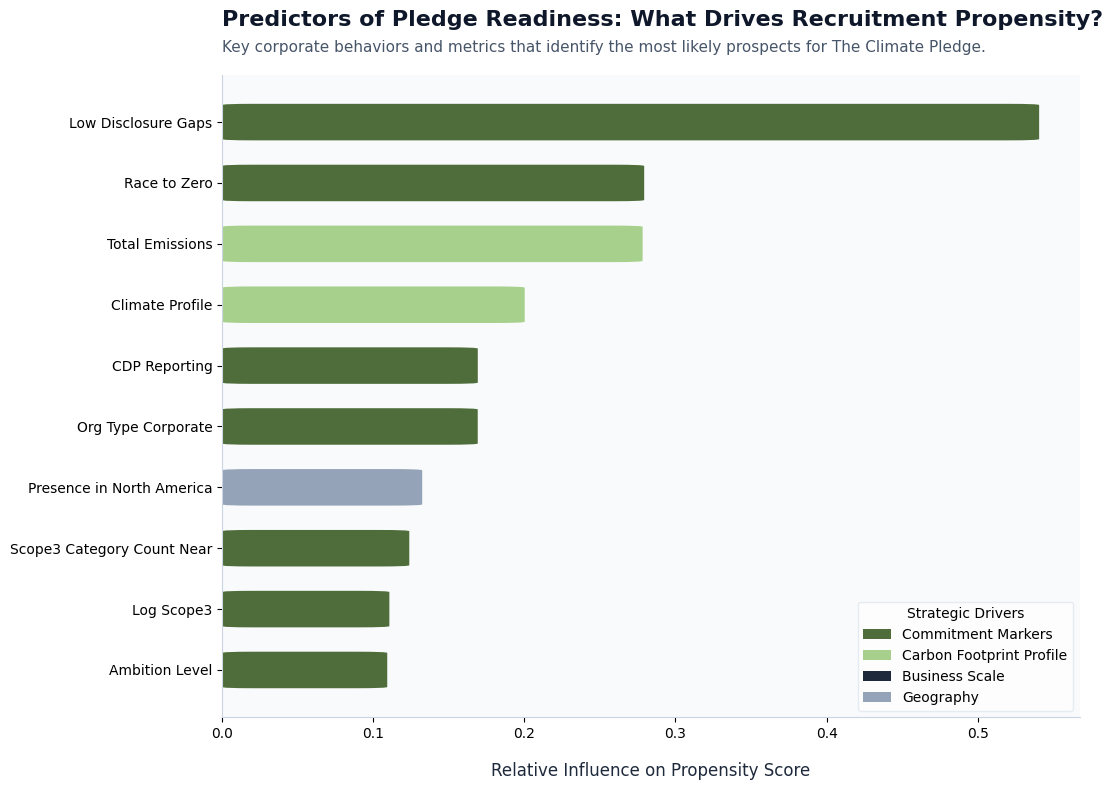

In [60]:

from matplotlib.patches import Patch, FancyBboxPatch
import re

# -------------------------------------------------------
# 1. Strategic color groups
# -------------------------------------------------------

_GROUP_HEX = {
    "Commitment": "#4F6D3A",
    "Footprint": "#A8D08D",
    "Scale": "#1e293b",
    "Geography": "#94a3b8",
}


# -------------------------------------------------------
# 2. Feature name mapping
# -------------------------------------------------------

_SHORT_ROW = [
    ("change_pct_s1s2_missing", "Low Disclosure Gaps", "Commitment"),
    ("scope1_missing", "Low Disclosure Gaps", "Commitment"),
    ("scope2_missing", "Low Disclosure Gaps", "Commitment"),
    ("has_near_term_target", "Transparency & Commitment", "Commitment"),
    ("ambition_level_nearterm", "Ambition Level", "Commitment"),
    ("race_to_zero", "Race to Zero", "Commitment"),
    ("in_cdp", "CDP Reporting", "Commitment"),
    ("log_revenue", "Revenue", "Scale"),
    ("log_employees", "Headcount", "Scale"),
    ("log_operational_intensity", "Carbon Intensity", "Footprint"),
    ("log_s1s2", "Total Emissions", "Footprint"),
    ("log_total_intensity", "Climate Profile", "Footprint"),
]

_EXACT = {row[0]: row[1:] for row in _SHORT_ROW}


def short_label_and_group(name):
    # Exact feature matches
    if name in _EXACT:
        return _EXACT[name][0], _EXACT[name][1]

    # Region dummy columns
    m_reg = re.match(r"^region_clean_(.+)$", name)
    if m_reg:
        region_name = m_reg.group(1).replace("_", " ").title()
        return f"Presence in {region_name}", "Geography"

    # Sector dummy columns
    m_sec = re.match(r"^sector_clean_(.+)$", name)
    if m_sec:
        sector_name = m_sec.group(1).replace("_", " ")

        if "logistics" in sector_name.lower():
            sector_name = "Logistics Sector"
        elif len(sector_name) > 28:
            sector_name = sector_name[:25] + "…"

        return sector_name.title(), "Geography"

    # Fallback label
    return name.replace("_", " ").title(), "Commitment"


# -------------------------------------------------------
# 3. Prepare SHAP importance table
# -------------------------------------------------------

shap_pub = shap_importance.copy()

labels_groups = [short_label_and_group(f) for f in shap_pub["feature"]]

shap_pub["short_label"] = [x[0] for x in labels_groups]
shap_pub["feature_group"] = [x[1] for x in labels_groups]

shap_pub = shap_pub.rename(columns={"mean_abs_shap": "importance"})

top_n = min(10, len(shap_pub))

plot_df = shap_pub.head(top_n).iloc[::-1].copy()

bar_colors = [
    _GROUP_HEX.get(group, "#64748b")
    for group in plot_df["feature_group"]
]


# -------------------------------------------------------
# 4. Create plot
# -------------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 8))

fig.patch.set_facecolor("#ffffff")
ax.set_facecolor("#f8fafc")

ax.grid(False)
ax.xaxis.grid(False)
ax.yaxis.grid(False)

bars = ax.barh(
    plot_df["short_label"],
    plot_df["importance"],
    color=bar_colors,
    height=0.6,
    edgecolor="none"
)


# -------------------------------------------------------
# 5. Add rounded bar style
# -------------------------------------------------------

for bar in bars:
    width = bar.get_width()
    height = bar.get_height()
    x, y = bar.get_xy()

    rounded_bar = FancyBboxPatch(
        (x, y),
        width,
        height,
        boxstyle="round,pad=0,rounding_size=0.02",
        ec="none",
        fc=bar.get_facecolor(),
        mutation_scale=1
    )

    ax.add_patch(rounded_bar)
    bar.set_visible(False)


# -------------------------------------------------------
# 6. Titles and labels
# -------------------------------------------------------

plt.title(
    "Predictors of Pledge Readiness: What Drives Recruitment Propensity?",
    fontsize=16,
    fontweight="bold",
    loc="left",
    pad=35,
    color="#0f172a"
)

plt.text(
    0,
    1.035,
    "Key corporate behaviors and metrics that identify the most likely prospects for The Climate Pledge.",
    transform=ax.transAxes,
    fontsize=11,
    color="#475569",
    ha="left"
)

ax.set_xlabel(
    "Relative Influence on Propensity Score",
    fontsize=12,
    fontweight="500",
    labelpad=15,
    color="#1e293b"
)


# -------------------------------------------------------
# 7. Clean axis styling
# -------------------------------------------------------

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.spines["left"].set_color("#cbd5e1")
ax.spines["bottom"].set_color("#cbd5e1")


# -------------------------------------------------------
# 8. Legend
# -------------------------------------------------------

legend_elements = [
    Patch(facecolor=_GROUP_HEX["Commitment"], label="Commitment Markers"),
    Patch(facecolor=_GROUP_HEX["Footprint"], label="Carbon Footprint Profile"),
    Patch(facecolor=_GROUP_HEX["Scale"], label="Business Scale"),
    Patch(facecolor=_GROUP_HEX["Geography"], label="Geography"),
]

ax.legend(
    handles=legend_elements,
    loc="lower right",
    frameon=True,
    facecolor="white",
    edgecolor="#e2e8f0",
    fontsize=10,
    title="Strategic Drivers"
)

plt.tight_layout()
plt.show()

* The SHAP analysis shows that the strongest drivers of TCP participation are related to transparency and commitment rather than emissions alone. Companies with fewer disclosure gaps, active participation in initiatives like Race to Zero, and CDP reporting are significantly more likely to join.

* While carbon footprint metrics such as total emissions and climate intensity do influence the model, they play a secondary role compared to behavioral indicators. 

* Geographic and structural factors have a smaller but noticeable effect, indicating that external context also contributes to participation likelihood.

#### 7e.PU Bagging Propensity Score with Uncertainty Penalty

* This step calculates the final propensity score from the PU Bagging ensemble.

* Each PU bagging model gives a predicted probability for every company. The average of these probabilities becomes the main `pu_score`. The standard deviation across bagging models becomes `pu_score_std`, which shows how much the models disagree.

* lower standard deviation means the ensemble is more confident. A higher standard deviation means the prediction is less stable. To account for this uncertainty, the final score applies a small penalty:

`pu_propensity_score = pu_score - 0.2 × pu_score_std`

* Companies are then ranked from highest to lowest based on this final uncertainty-adjusted propensity score.

In [55]:
# Get predicted probability from each PU bagging model
bag_scores = []

for model in final_pu_models:
    score = model.predict_proba(X_all)[:, 1]
    bag_scores.append(score)

# Convert list of scores into matrix
bag_scores = np.vstack(bag_scores)

# Average score across all PU models
df_enc["pu_score"] = bag_scores.mean(axis=0)

# Standard deviation shows prediction uncertainty
df_enc["pu_score_std"] = bag_scores.std(axis=0)

# Apply uncertainty penalty
# Higher uncertainty slightly lowers final score
df_enc["pu_propensity_score"] = (
    df_enc["pu_score"] - 0.2 * df_enc["pu_score_std"]
)

# Rank companies by final propensity score
df_enc["rank"] = df_enc["pu_propensity_score"].rank(
    ascending=False,
    method="first"
).astype(int)

# Show top-ranked companies
df_enc.sort_values("pu_propensity_score", ascending=False)[
    ["pu_score", "pu_score_std", "pu_propensity_score", "rank"]
].head(20)

,pu_score,pu_score_std,pu_propensity_score,rank
4750,0.993094,0.001078,0.992878,1
4704,0.992753,0.001343,0.992484,2
4708,0.992244,0.001585,0.991927,3
4700,0.992214,0.001502,0.991913,4
4713,0.991927,0.001405,0.991646,5
4671,0.991771,0.001729,0.991425,6
4740,0.991672,0.001552,0.991362,7
4727,0.991435,0.001195,0.991196,8
4710,0.991160,0.001556,0.990849,9
4709,0.990937,0.001376,0.990662,10


In [56]:
df_enc[df_enc[TARGET_COL] == 0].sort_values(
    "pu_propensity_score", ascending=False
).head(20)

,company_name_sbti,sbti_id,company_name_clean,isin,lei,organization_type,location,region,sector,has_near_term_target,...,sector_clean_Unknown,org_type_Corporate,org_type_Financial_Institution,org_type_SME,region_clean,sector_clean,pu_score,pu_score_std,pu_propensity_score,rank
208,AstraZeneca,40001319.0,ASTRAZENECA,GB0009895292,PY6ZZQWO2IZFZC3IOL08,Corporate,United Kingdom,Europe,"Pharmaceuticals, Biotechnology and Life Sciences",1.0,...,False,True,False,False,Europe,Technology & Electronics,0.859969,0.083347,0.843299,180
346,BT Group,40017584.0,BT GROUP,GB0030913577,213800LRO7NS5CYQMN21,Corporate,United Kingdom,Europe,Telecommunication Services,1.0,...,False,True,False,False,Europe,Public & Services,0.815870,0.091352,0.797600,191
82,"Adobe, Inc.",40002432.0,ADOBE,US00724F1012,FU4LY2G4933NH2E1CP29,Corporate,United States of America,Northern America,Software and Services,1.0,...,False,True,False,False,North America,Technology & Electronics,0.775290,0.055064,0.764277,197
941,HOK,40011426.0,HOK,NaN,549300G9E8K26JED2T84,Corporate,United States of America,Northern America,Professional Services,1.0,...,False,True,False,False,North America,Public & Services,0.777419,0.090441,0.759331,199
1658,SANOFI,40012670.0,SANOFI,FR0000120578,549300E9PC51EN656011,Corporate,France,Europe,"Pharmaceuticals, Biotechnology and Life Sciences",1.0,...,False,True,False,False,Europe,Technology & Electronics,0.764166,0.098587,0.744449,204
713,Expanscience,40000314.0,EXPANSCIENCE,NaN,969500C4Z0KZ5S29WM22,Corporate,France,Europe,"Pharmaceuticals, Biotechnology and Life Sciences",1.0,...,False,True,False,False,Europe,Technology & Electronics,0.758572,0.111278,0.736317,208
2800,Swissport International,40006221.0,SWISSPORT INTERNATIONAL,NaN,NaN,Corporate,Switzerland,Europe,Air Freight Transportation and Logistics,1.0,...,False,True,False,False,Europe,Transportation & Logistics,0.728492,0.085325,0.711427,214
1919,Tesco,40010607.0,TESCO,GB0008847096,2138002P5RNKC5W2JZ46,Corporate,United Kingdom,Europe,Food and Staples Retailing,1.0,...,False,True,False,False,Europe,Retail & Consumer,0.729782,0.092877,0.711206,215
1197,Loxam,40007655.0,LOXAM,XS2031871143,969500BNA2YRNE1R5K91,Corporate,France,Europe,"Trading Companies and Distributors, and Commer...",1.0,...,False,True,False,False,Europe,Public & Services,0.739493,0.141600,0.711174,216
567,Dell Technologies,40003670.0,DELL TECHNOLOGIES,US24703L1035,549300TJB5YBRUPOG437,Corporate,United States of America,Northern America,Technology Hardware and Equipment,1.0,...,False,True,False,False,North America,Technology & Electronics,0.724653,0.093211,0.706011,217


#### 7f .Generate propensity scores for all non-TCP companies

In [62]:
from pathlib import Path

# -------------------------------------------------------
# 1. Rank non-TCP companies only
# -------------------------------------------------------

non_tcp_ranked = df_enc[df_enc[TARGET_COL] == 0].copy()

non_tcp_ranked = non_tcp_ranked.sort_values(
    "pu_propensity_score",
    ascending=False
).reset_index(drop=True)

non_tcp_ranked["non_tcp_rank"] = non_tcp_ranked.index + 1

display(non_tcp_ranked.head(20))


# -------------------------------------------------------
# 2. Create final scores dataframe
# -------------------------------------------------------

final_scores_df = df_enc.copy()

# Add useful columns back from df_model if available
sync_cols = [
    "region_clean",
    "sector_clean",
    "operational_intensity",
    "employee_intensity",
]

for col in sync_cols:
    if col in df_model.columns:
        final_scores_df[col] = df_model[col]


# -------------------------------------------------------
# 3. Recompute PU scores if missing
# -------------------------------------------------------

required_score_cols = {
    "pu_propensity_score",
    "pu_score",
    "pu_score_std"
}

missing_score_cols = sorted(required_score_cols - set(final_scores_df.columns))

if missing_score_cols:
    if "final_pu_models" not in globals() or not final_pu_models:
        raise RuntimeError(
            "PU scores are missing. Run the PU training cells first."
        )

    print("PU scores missing, so they are being recomputed from final_pu_models.")

    X_pu = (
        df_enc[FEATURE_COLS]
        .reset_index(drop=True)
        .apply(pd.to_numeric, errors="coerce")
        .fillna(0)
        .astype(np.float64)
    )

    bag_scores = np.vstack([
        model.predict_proba(X_pu)[:, 1]
        for model in final_pu_models
    ])

    final_scores_df["pu_score"] = bag_scores.mean(axis=0)
    final_scores_df["pu_score_std"] = bag_scores.std(axis=0)

    final_scores_df["pu_propensity_score"] = (
        final_scores_df["pu_score"] - 0.2 * final_scores_df["pu_score_std"]
    )

    df_enc["pu_score"] = final_scores_df["pu_score"]
    df_enc["pu_score_std"] = final_scores_df["pu_score_std"]
    df_enc["pu_propensity_score"] = final_scores_df["pu_propensity_score"]


# -------------------------------------------------------
# 4. Add overall and non-TCP ranks
# -------------------------------------------------------

final_scores_df["overall_rank"] = (
    final_scores_df["pu_propensity_score"]
    .rank(ascending=False, method="first")
    .astype(int)
)

non_tcp_mask = final_scores_df[TARGET_COL] == 0

final_scores_df["non_tcp_rank"] = np.nan

final_scores_df.loc[non_tcp_mask, "non_tcp_rank"] = (
    final_scores_df.loc[non_tcp_mask, "pu_propensity_score"]
    .rank(ascending=False, method="first")
)


# -------------------------------------------------------
# 5. Export selected columns
# -------------------------------------------------------

export_path = Path(
    "C:/Users/Nidhi/Documents/College Material/Winter Quarter 2025/Capstone-1/Data/code/output_tcp_propensity_export.csv"
)

export_cols = [
    "company_name_clean",
    "sbti_id",
    "region_clean",
    "sector_clean",
    "scope1",
    "scope2_location",
    "scope2_market",
    "scope3",
    "log_s1s2",
    "log_scope3",
    "log_revenue",
    "log_employees",
    "log_operational_intensity",
    "log_total_intensity",
    "operational_intensity",
    "employee_intensity",
    "revenue_clean",
    "employees_clean",
    TARGET_COL,
    "pu_propensity_score",
    "overall_rank",
    "non_tcp_rank",
]

export_cols = [col for col in export_cols if col in final_scores_df.columns]

export_df = final_scores_df[export_cols].copy()

export_df = export_df.rename(
    columns={
        "sbti_id": "clean_id",
        TARGET_COL: "joined_tcp"
    }
)

export_path.parent.mkdir(parents=True, exist_ok=True)

export_df.to_csv(export_path, index=False)

print(f"Saved {export_df.shape[0]} rows to {export_path.resolve()}")

,company_name_sbti,sbti_id,company_name_clean,isin,lei,organization_type,location,region,sector,has_near_term_target,...,org_type_Corporate,org_type_Financial_Institution,org_type_SME,region_clean,sector_clean,pu_score,pu_score_std,pu_propensity_score,rank,non_tcp_rank
0,AstraZeneca,40001319.0,ASTRAZENECA,GB0009895292,PY6ZZQWO2IZFZC3IOL08,Corporate,United Kingdom,Europe,"Pharmaceuticals, Biotechnology and Life Sciences",1.0,...,True,False,False,Europe,Technology & Electronics,0.859969,0.083347,0.843299,180,1
1,BT Group,40017584.0,BT GROUP,GB0030913577,213800LRO7NS5CYQMN21,Corporate,United Kingdom,Europe,Telecommunication Services,1.0,...,True,False,False,Europe,Public & Services,0.815870,0.091352,0.797600,191,2
2,"Adobe, Inc.",40002432.0,ADOBE,US00724F1012,FU4LY2G4933NH2E1CP29,Corporate,United States of America,Northern America,Software and Services,1.0,...,True,False,False,North America,Technology & Electronics,0.775290,0.055064,0.764277,197,3
3,HOK,40011426.0,HOK,NaN,549300G9E8K26JED2T84,Corporate,United States of America,Northern America,Professional Services,1.0,...,True,False,False,North America,Public & Services,0.777419,0.090441,0.759331,199,4
4,SANOFI,40012670.0,SANOFI,FR0000120578,549300E9PC51EN656011,Corporate,France,Europe,"Pharmaceuticals, Biotechnology and Life Sciences",1.0,...,True,False,False,Europe,Technology & Electronics,0.764166,0.098587,0.744449,204,5
5,Expanscience,40000314.0,EXPANSCIENCE,NaN,969500C4Z0KZ5S29WM22,Corporate,France,Europe,"Pharmaceuticals, Biotechnology and Life Sciences",1.0,...,True,False,False,Europe,Technology & Electronics,0.758572,0.111278,0.736317,208,6
6,Swissport International,40006221.0,SWISSPORT INTERNATIONAL,NaN,NaN,Corporate,Switzerland,Europe,Air Freight Transportation and Logistics,1.0,...,True,False,False,Europe,Transportation & Logistics,0.728492,0.085325,0.711427,214,7
7,Tesco,40010607.0,TESCO,GB0008847096,2138002P5RNKC5W2JZ46,Corporate,United Kingdom,Europe,Food and Staples Retailing,1.0,...,True,False,False,Europe,Retail & Consumer,0.729782,0.092877,0.711206,215,8
8,Loxam,40007655.0,LOXAM,XS2031871143,969500BNA2YRNE1R5K91,Corporate,France,Europe,"Trading Companies and Distributors, and Commer...",1.0,...,True,False,False,Europe,Public & Services,0.739493,0.141600,0.711174,216,9
9,Dell Technologies,40003670.0,DELL TECHNOLOGIES,US24703L1035,549300TJB5YBRUPOG437,Corporate,United States of America,Northern America,Technology Hardware and Equipment,1.0,...,True,False,False,North America,Technology & Electronics,0.724653,0.093211,0.706011,217,10


Saved 4759 rows to C:\Users\Nidhi\Documents\College Material\Winter Quarter 2025\Capstone-1\Data\code\output_tcp_propensity_export.csv
